# Resampling — Rebalancing the Training Set

Stratification keeps a bad ratio from getting *worse* in any one fold, but it does not change the
ratio. When one class is ten times rarer than the other, most classifiers learn that predicting the
majority is a reliable way to be right, and the minority class is effectively ignored.

**Resampling** attacks the ratio itself, by duplicating minority examples or discarding majority
ones until the training set is balanced. This notebook runs the same models three ways — untouched,
manually resampled, and resampled with `imbalanced-learn` — on a deliberately 10:1 dataset.

## Learning objectives

- Diagnose the failure mode of a classifier trained on imbalanced data using per-class recall
- Balance a training set by hand with `np.random.choice`
- Use `imblearn`'s `RandomOverSampler` to do the same thing in one call
- Explain why resampling must be applied to the training split only
- Weigh the cost of oversampling (duplicated points) against undersampling (discarded data)

## Background

This notebook assumes the classification metrics — precision, recall, $F_1$, and the confusion
matrix — from `U1-6_Classify-3_F1Score`, and the decision-region plots from
`U1-6_Classify-1_CompareRegions`.

`imbalanced-learn` is a separate package from scikit-learn but follows the same API; a commented
`pip install` line is included below.

**Prerequisites:** `U1-6_Classify-3_F1Score` (metrics),
`U1-7_Imbalance-1_StratifiedKFold` (why imbalance breaks naive evaluation)

**Dataset:** none — two 2-D Gaussian clouds from `GenerateData`, at a 1000:100 (10:1) ratio.

**References:** https://imbalanced-learn.org/stable/references/over_sampling.html

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

pd.set_option('display.max_columns',100)
pd.set_option('display.max_rows',100)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

# Shared course helpers (msds565_helpers.py lives in the repo root).
# Notebooks sit two folders below the root, so '../..' points back to it.
import sys
sys.path.append('../..')
import msds565_helpers as helpers

## 1. Tools: entropy, region painting, and the data generator

Three helpers carried across the imbalance notebooks.

`GenerateData(n_pts0, n_pts1, center_sep, std)` draws two 2-D Gaussian clouds with a controllable
**imbalance ratio** — the two counts are independent, so a 10:1 or 4:1 split is one argument away —
and a controllable **overlap** via `center_sep` and `std`. Imbalance and overlap are separate
problems and this lets us vary them separately.

`entropy` and `visualize_regions` are the decision-region tools from
`U1-6_Classify-1_CompareRegions`: predict on a dense grid, reshape into an image, and return both
the predicted class and the entropy of the predicted probabilities at each point.

In [2]:
import math

def entropy( x, b ):
    s = 0
    for p in x:
        if p > 0:
            s += -p*math.log(p,b)
        # end
    # end
    return s
# end

def visualize_regions(model, MAX, nGrid):
    a1 = np.linspace(-MAX, MAX, nGrid)
    a2 = np.linspace(-MAX, MAX, nGrid)

    A1, A2 = np.meshgrid(a1, a2)
    A1 = A1.flatten()
    A2 = A2.flatten()
    A = np.vstack((A1, A2)).T

    # Predict B
    B = model.predict(A)
    B = B.reshape(nGrid, nGrid)
    B = np.flipud(B)

    # Compute entropy for S
    prob_2D = model.predict_proba(A)
    S = np.array([entropy(p, 2) for p in prob_2D])
    S = S.reshape(nGrid, nGrid)
    S = np.flipud(S)

    return B, S
# end
    
def GenerateData(n_pts1,n_pts2,center_sep,std):
    
    cov = std**2*np.eye(2)
    
    x1 = np.random.multivariate_normal(mean=[-center_sep/2,0],
                                       cov=cov,
                                       size=n_pts1)
    y1 = np.zeros(n_pts1)
    
    x2 = np.random.multivariate_normal(mean=[center_sep/2,0],
                                       cov=cov,
                                       size=n_pts2)
    y2 = np.ones(n_pts2)
    
    X = np.concatenate((x1,x2),axis=0)
    y = np.concatenate((y1,y2),axis=0).astype(int)
    
    return X, y
# end

## 2. Create the data

A 10:1 imbalance — 1,000 points in class 0 against 100 in class 1 — with the clouds close enough
(`center_sep = 1.5`, `std = 0.8`) that they genuinely overlap. Both knobs are worth changing:
widening `center_sep` makes the classes separable and the imbalance stops mattering much, while
raising `n_pts1` toward `n_pts0` removes the imbalance and isolates the overlap.

The seed is commented out, so each run draws a fresh sample.

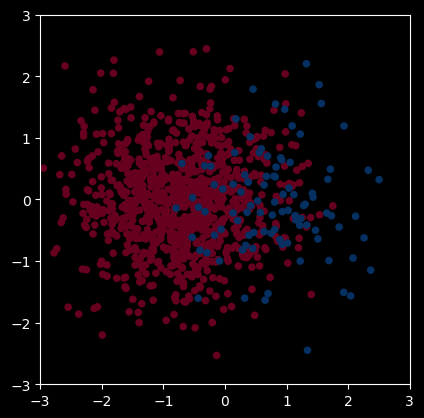

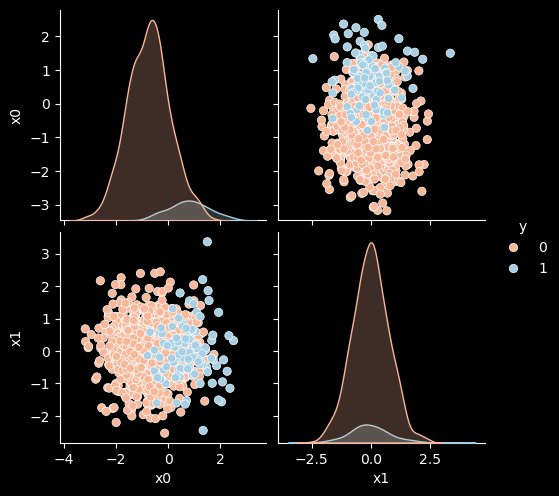

In [3]:
#np.random.seed(0)

n_pts0     = 1000
n_pts1     = 100
std        = 0.8
center_sep = 1.5

# generate data
X, y = GenerateData(
    n_pts0,
    n_pts1,
    center_sep,
    std
)

MAX = np.max(np.abs(X))

cmap = 'RdBu'

plt_scale = 3
plt.scatter(X[:,0], X[:,1], c=y, s=20, cmap=cmap)
plt.xlim(-plt_scale,plt_scale)
plt.ylim(-plt_scale,plt_scale)
plt.gca().set_aspect('equal')
plt.show()

df = pd.DataFrame( {"x0":X[:,0], "x1":X[:,1], "y":y} )
sns.pairplot(df, hue='y', palette='RdBu')
plt.show()

## 3. Modeling without balancing

The baseline, and the failure to be fixed.

Read the **confusion matrices and per-class recall**, not the accuracy. With a 10:1 split, a model
that predicts class 0 for everything scores about 91% accuracy — and has recall 0 on class 1. That
is the number to watch: it is entirely possible for a model here to be "91% accurate" and completely
useless for finding the rare class.

`stratify=y` in the split keeps the 10:1 ratio in both train and test, so the test set remains a
fair sample of the real problem.

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
)

print("Original data:")
print(pd.Series(y).value_counts())
print()
print("Training data:")
print(pd.Series(y_train).value_counts())
print()
print("Testing data:")
print(pd.Series(y_test).value_counts())

Original data:
0    1000
1     100
Name: count, dtype: int64

Training data:
0    800
1     80
Name: count, dtype: int64

Testing data:
0    200
1     20
Name: count, dtype: int64


In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

models = [
    LogisticRegression(),
    KNeighborsClassifier(n_neighbors=1,   weights='uniform'),
    KNeighborsClassifier(n_neighbors=5,   weights='uniform'),
    KNeighborsClassifier(n_neighbors=10,  weights='uniform'),
    KNeighborsClassifier(n_neighbors=50,  weights='uniform'),
    RandomForestClassifier(n_estimators=10,  max_leaf_nodes=3),
    RandomForestClassifier(n_estimators=10,  max_leaf_nodes=10),
    RandomForestClassifier(n_estimators=100, max_leaf_nodes=3),
    RandomForestClassifier(n_estimators=100, max_leaf_nodes=10),
    RandomForestClassifier(n_estimators=100, max_leaf_nodes=30),
    GradientBoostingClassifier(n_estimators=10,  learning_rate=0.1, max_leaf_nodes=3),
    GradientBoostingClassifier(n_estimators=10,  learning_rate=0.1, max_leaf_nodes=10),
    GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_leaf_nodes=3),
    GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_leaf_nodes=10),
]

LogisticRegression()
              precision    recall  f1-score   support

           0       0.93      0.98      0.96       200
           1       0.62      0.25      0.36        20

    accuracy                           0.92       220
   macro avg       0.78      0.62      0.66       220
weighted avg       0.90      0.92      0.90       220



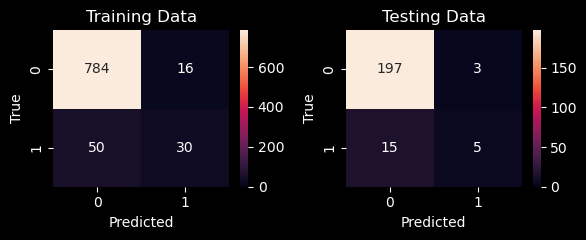

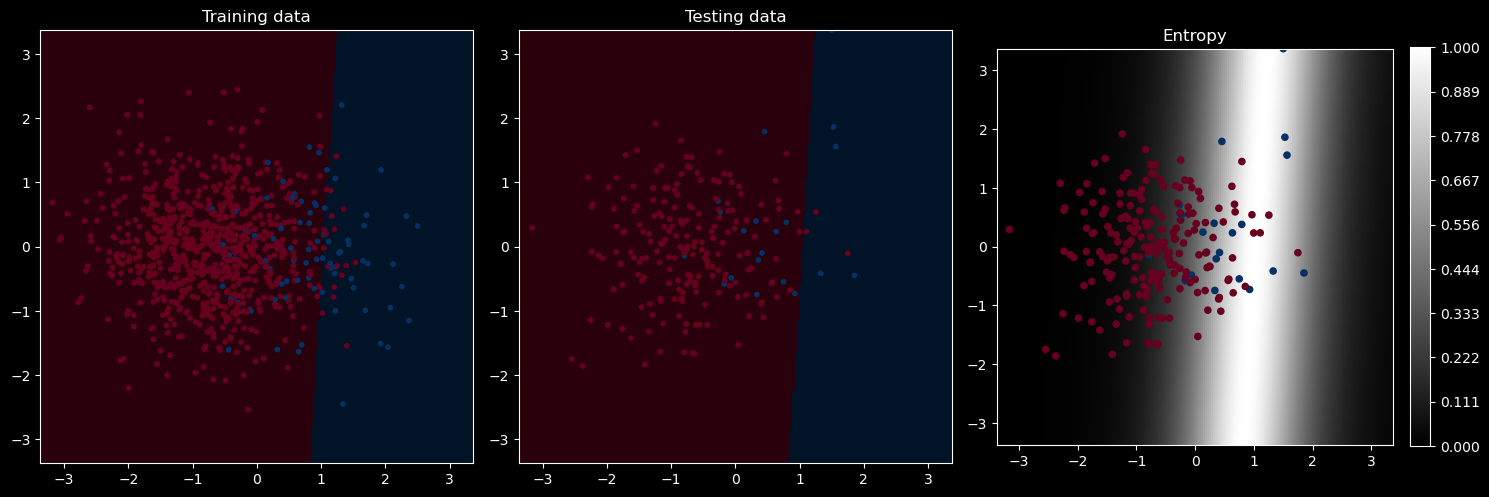

KNeighborsClassifier(n_neighbors=1)
              precision    recall  f1-score   support

           0       0.93      0.94      0.94       200
           1       0.33      0.30      0.32        20

    accuracy                           0.88       220
   macro avg       0.63      0.62      0.63       220
weighted avg       0.88      0.88      0.88       220



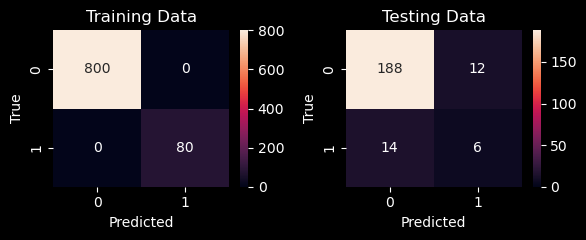

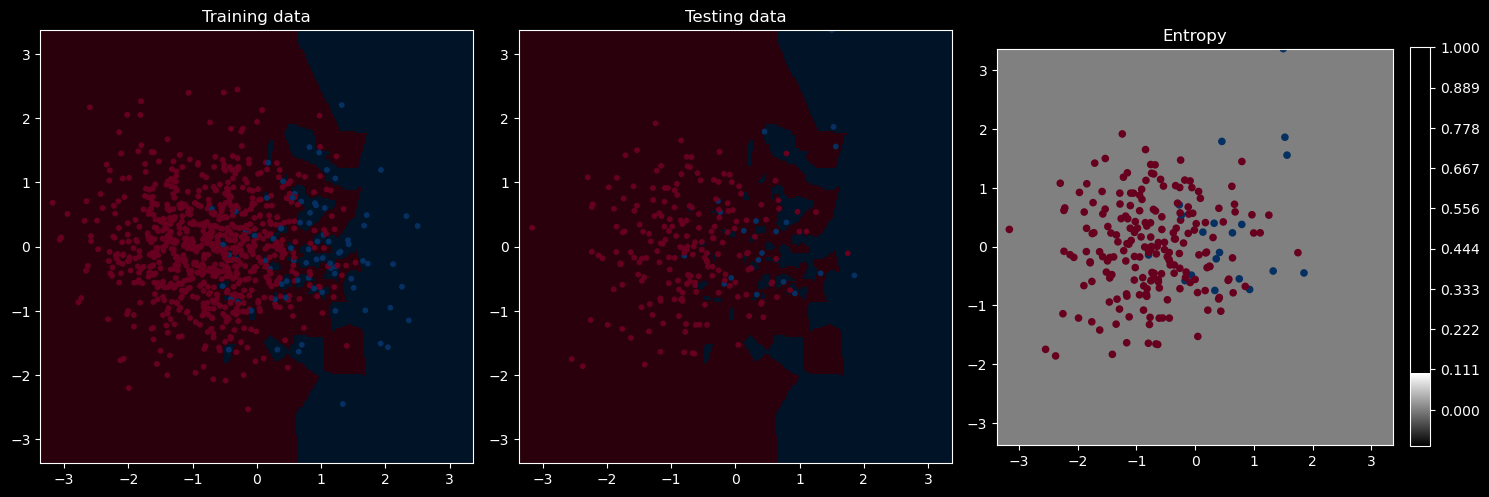

KNeighborsClassifier()
              precision    recall  f1-score   support

           0       0.92      0.98      0.95       200
           1       0.43      0.15      0.22        20

    accuracy                           0.90       220
   macro avg       0.67      0.56      0.59       220
weighted avg       0.88      0.90      0.88       220



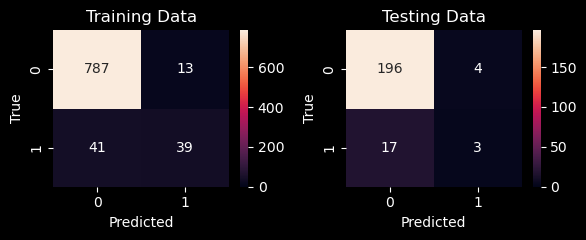

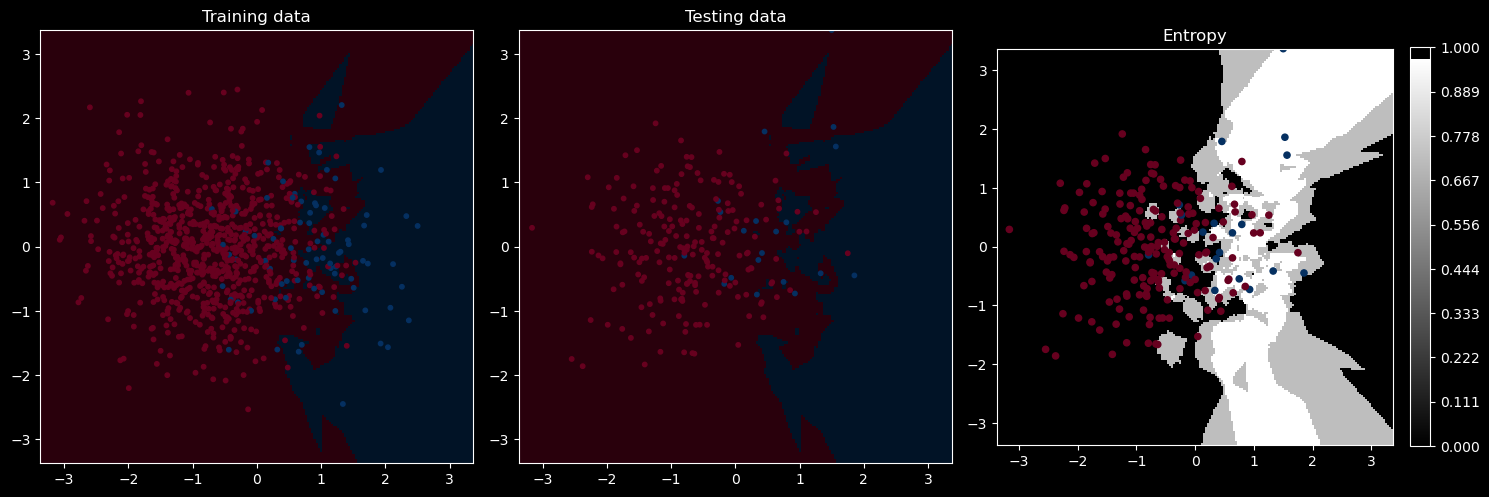

KNeighborsClassifier(n_neighbors=10)
              precision    recall  f1-score   support

           0       0.92      0.99      0.95       200
           1       0.60      0.15      0.24        20

    accuracy                           0.91       220
   macro avg       0.76      0.57      0.60       220
weighted avg       0.89      0.91      0.89       220



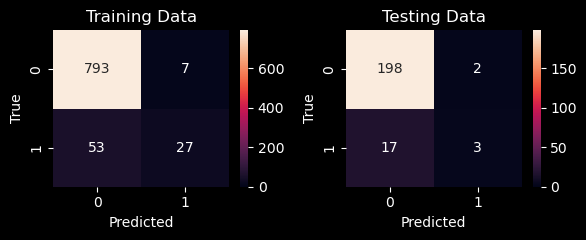

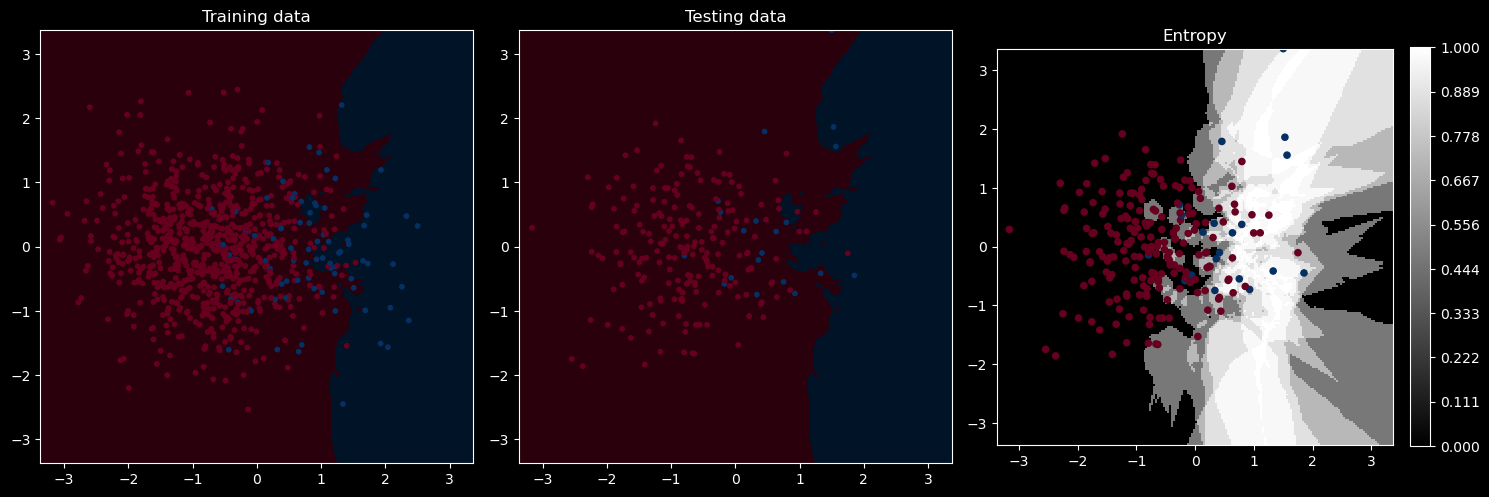

KNeighborsClassifier(n_neighbors=50)
              precision    recall  f1-score   support

           0       0.91      0.99      0.95       200
           1       0.50      0.05      0.09        20

    accuracy                           0.91       220
   macro avg       0.71      0.52      0.52       220
weighted avg       0.88      0.91      0.87       220



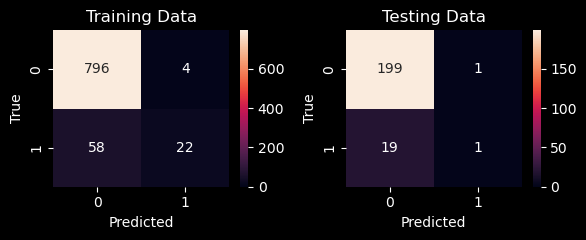

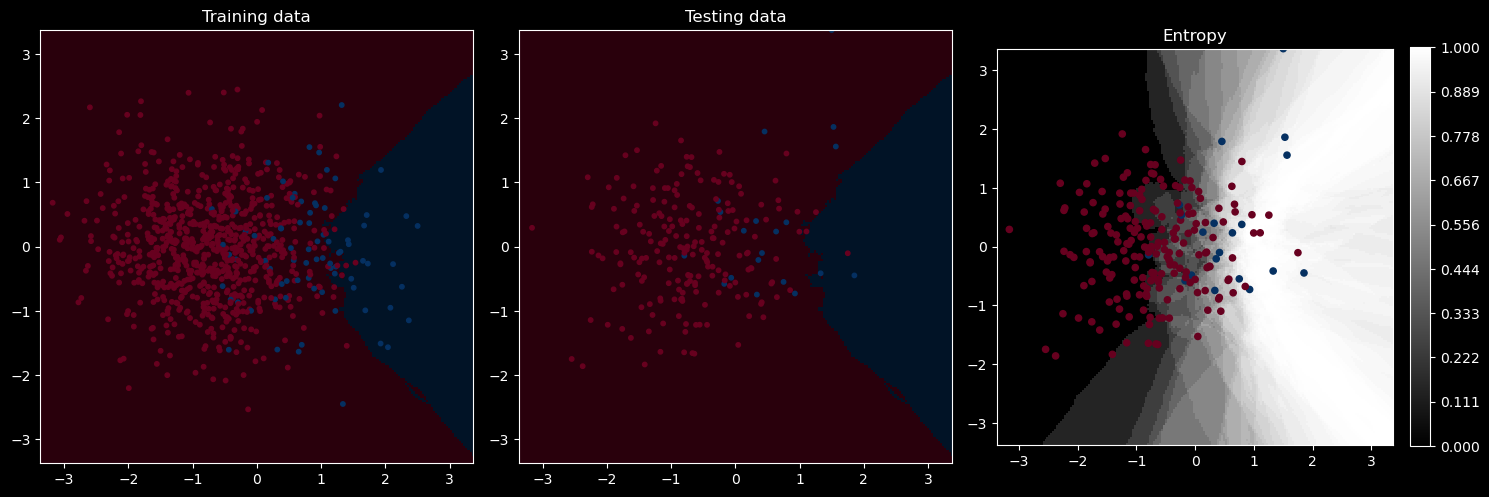

RandomForestClassifier(max_leaf_nodes=3, n_estimators=10)
              precision    recall  f1-score   support

           0       0.92      0.99      0.95       200
           1       0.67      0.10      0.17        20

    accuracy                           0.91       220
   macro avg       0.79      0.55      0.56       220
weighted avg       0.89      0.91      0.88       220



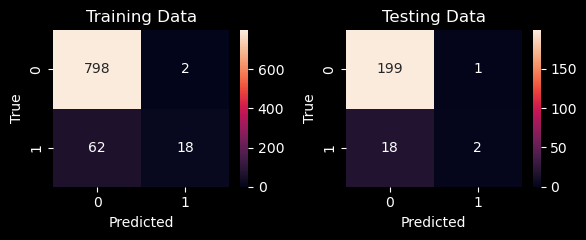

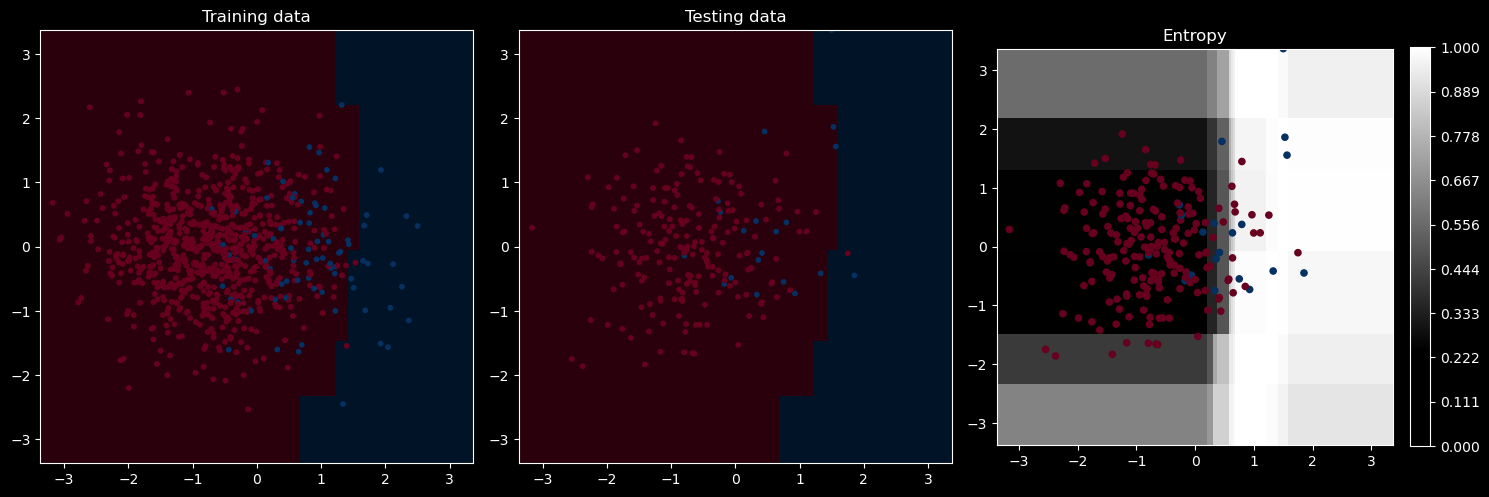

RandomForestClassifier(max_leaf_nodes=10, n_estimators=10)
              precision    recall  f1-score   support

           0       0.93      0.99      0.96       200
           1       0.83      0.25      0.38        20

    accuracy                           0.93       220
   macro avg       0.88      0.62      0.67       220
weighted avg       0.92      0.93      0.91       220



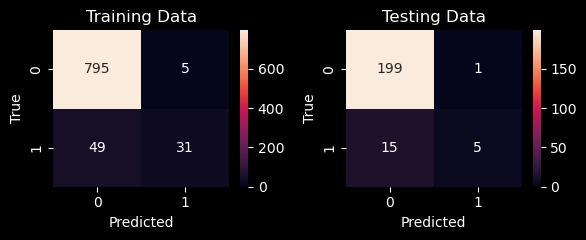

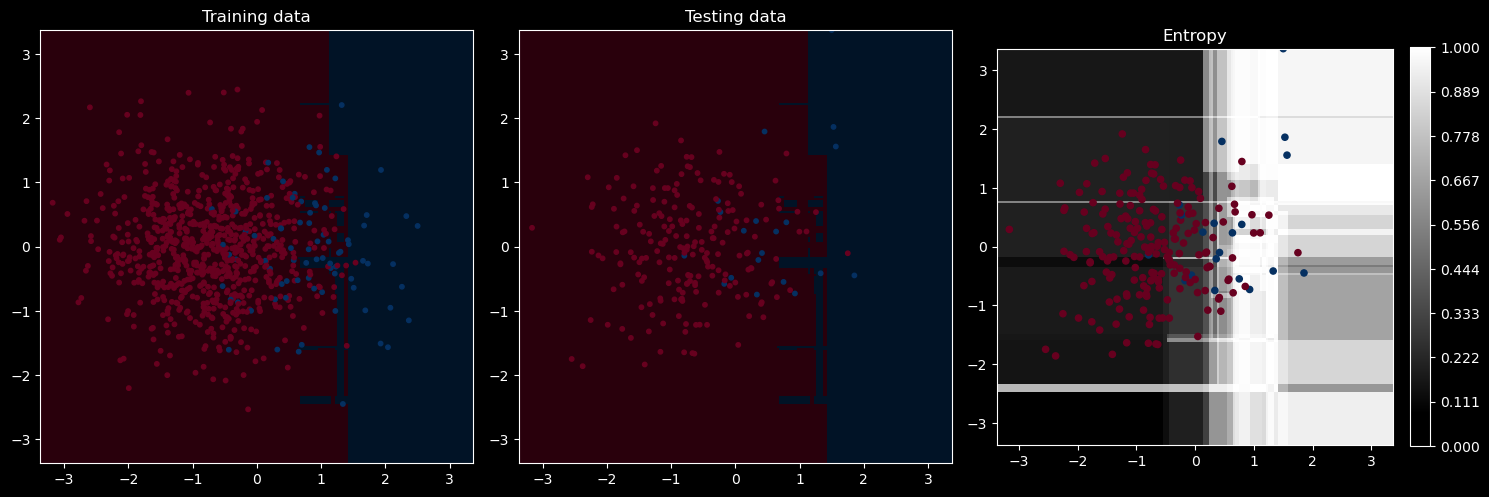

RandomForestClassifier(max_leaf_nodes=3)
              precision    recall  f1-score   support

           0       0.91      1.00      0.95       200
           1       0.00      0.00      0.00        20

    accuracy                           0.91       220
   macro avg       0.45      0.50      0.48       220
weighted avg       0.83      0.91      0.87       220



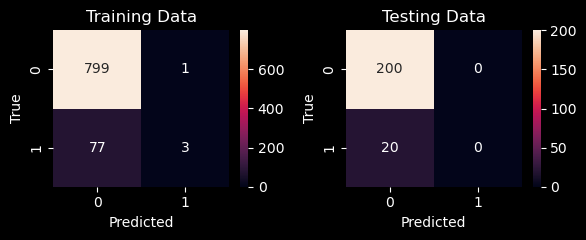

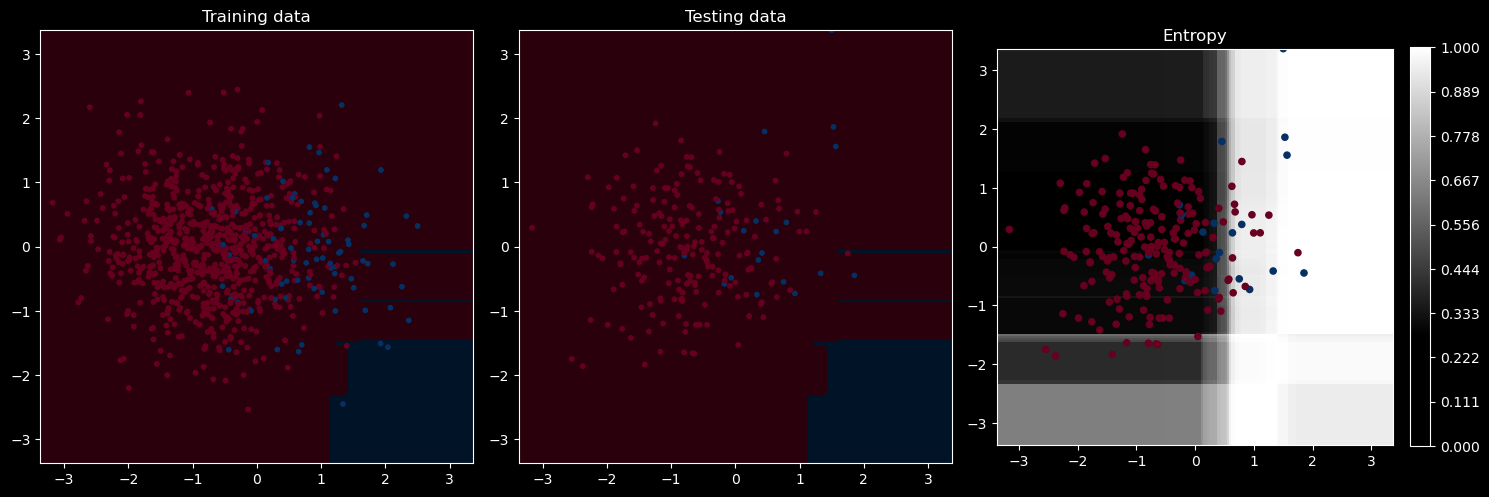

RandomForestClassifier(max_leaf_nodes=10)
              precision    recall  f1-score   support

           0       0.93      0.97      0.95       200
           1       0.50      0.30      0.38        20

    accuracy                           0.91       220
   macro avg       0.72      0.64      0.66       220
weighted avg       0.89      0.91      0.90       220



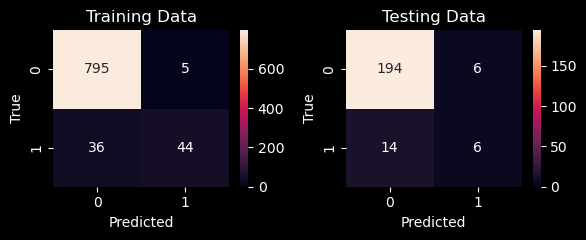

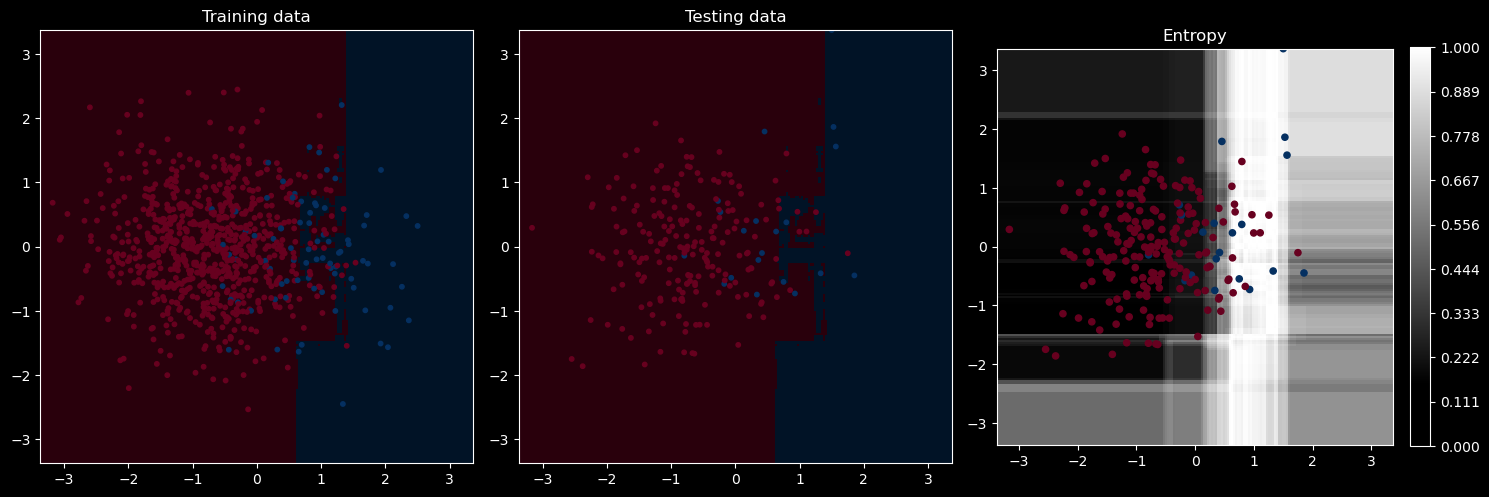

RandomForestClassifier(max_leaf_nodes=30)
              precision    recall  f1-score   support

           0       0.93      0.97      0.95       200
           1       0.55      0.30      0.39        20

    accuracy                           0.91       220
   macro avg       0.74      0.64      0.67       220
weighted avg       0.90      0.91      0.90       220



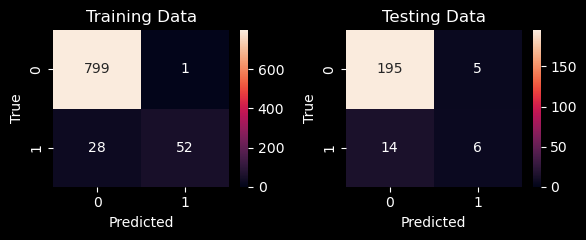

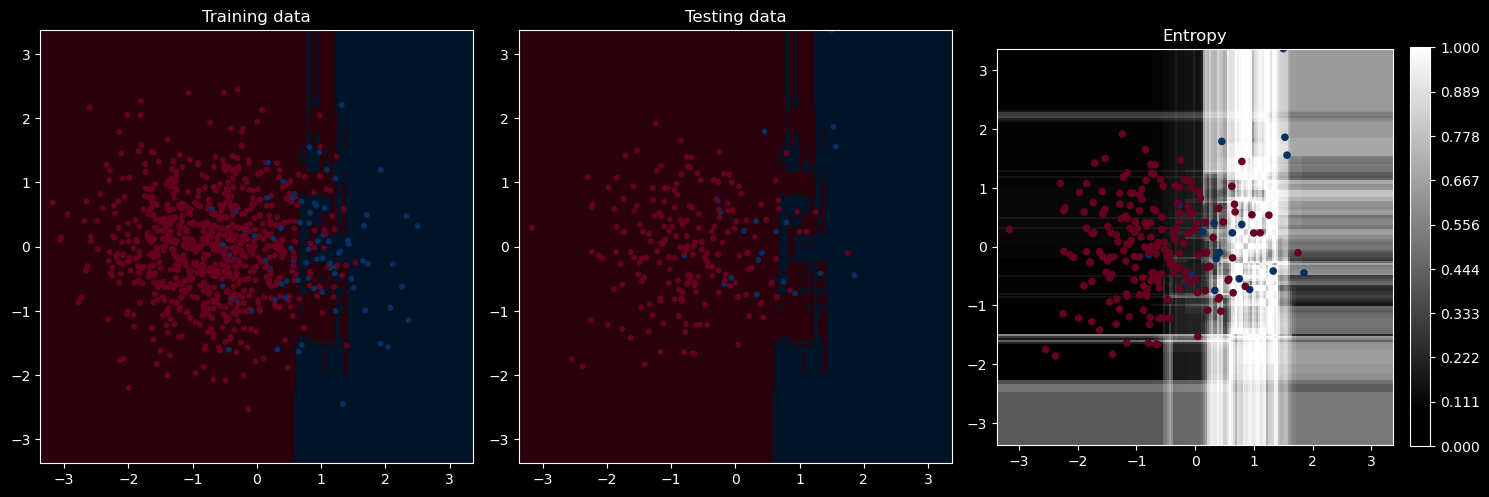

GradientBoostingClassifier(max_leaf_nodes=3, n_estimators=10)
              precision    recall  f1-score   support

           0       0.93      0.99      0.96       200
           1       0.80      0.20      0.32        20

    accuracy                           0.92       220
   macro avg       0.86      0.60      0.64       220
weighted avg       0.91      0.92      0.90       220



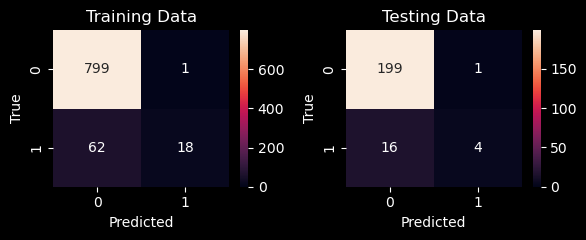

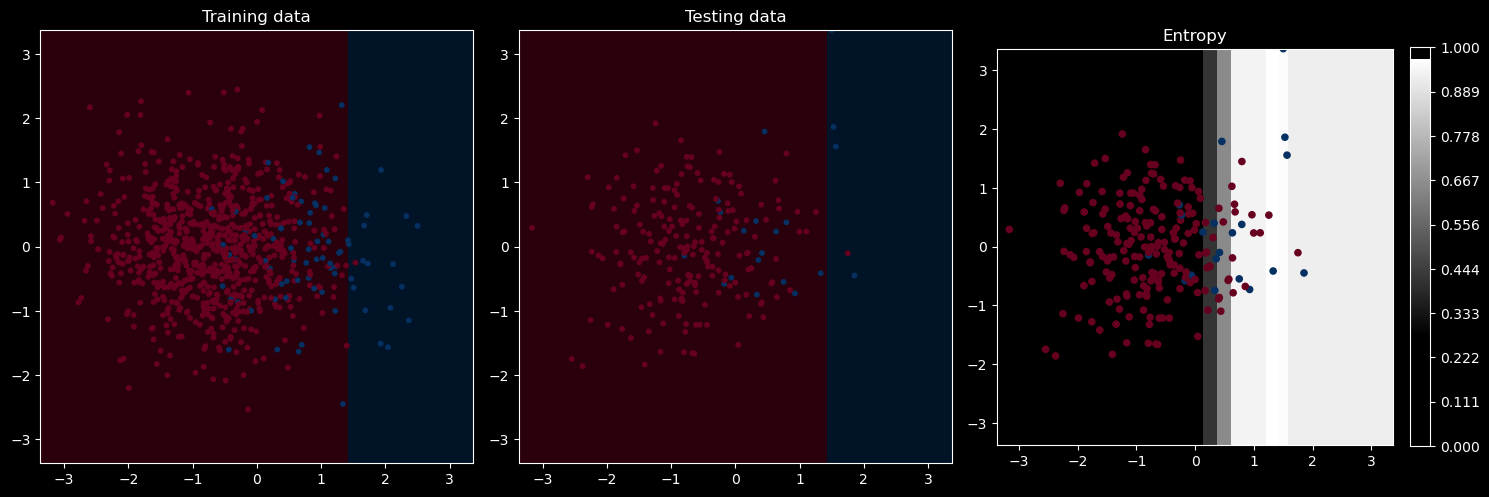

GradientBoostingClassifier(max_leaf_nodes=10, n_estimators=10)
              precision    recall  f1-score   support

           0       0.93      0.99      0.96       200
           1       0.80      0.20      0.32        20

    accuracy                           0.92       220
   macro avg       0.86      0.60      0.64       220
weighted avg       0.91      0.92      0.90       220



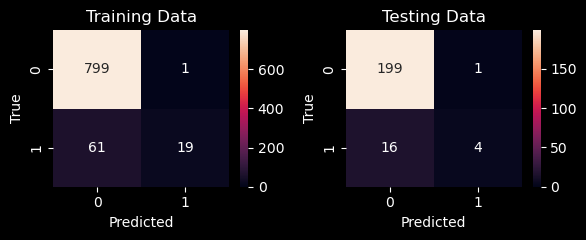

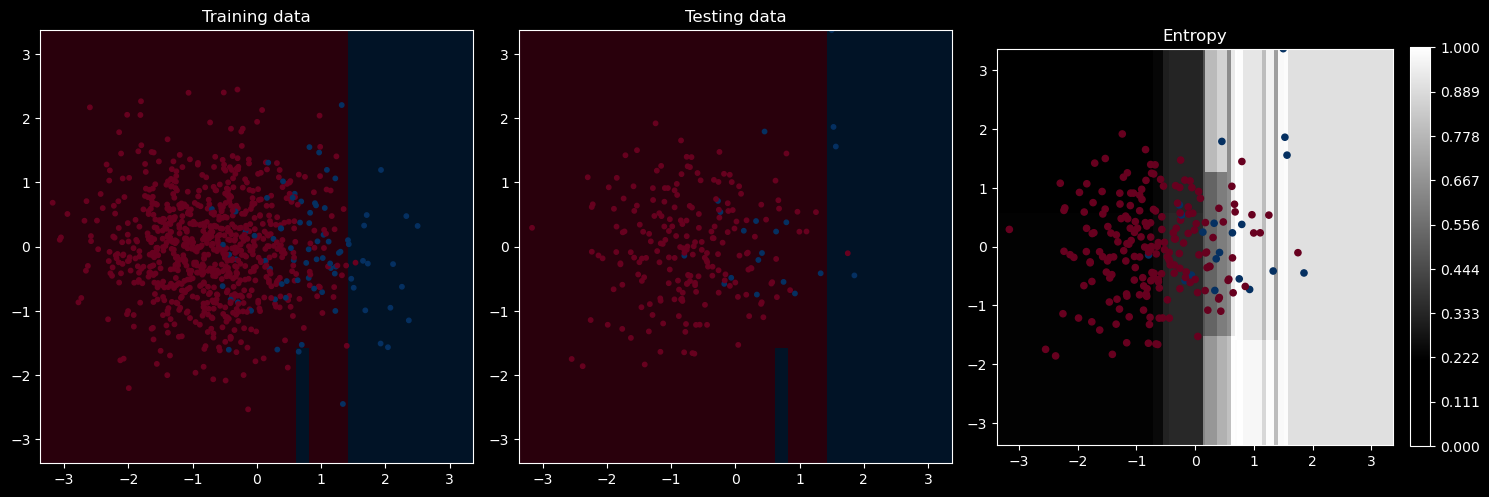

GradientBoostingClassifier(max_leaf_nodes=3)
              precision    recall  f1-score   support

           0       0.93      0.97      0.95       200
           1       0.50      0.30      0.38        20

    accuracy                           0.91       220
   macro avg       0.72      0.64      0.66       220
weighted avg       0.89      0.91      0.90       220



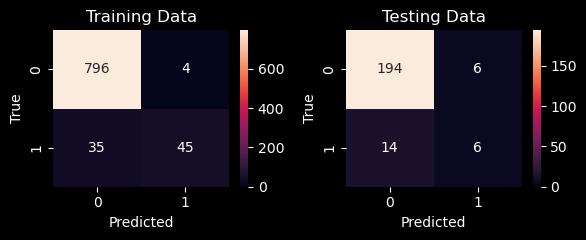

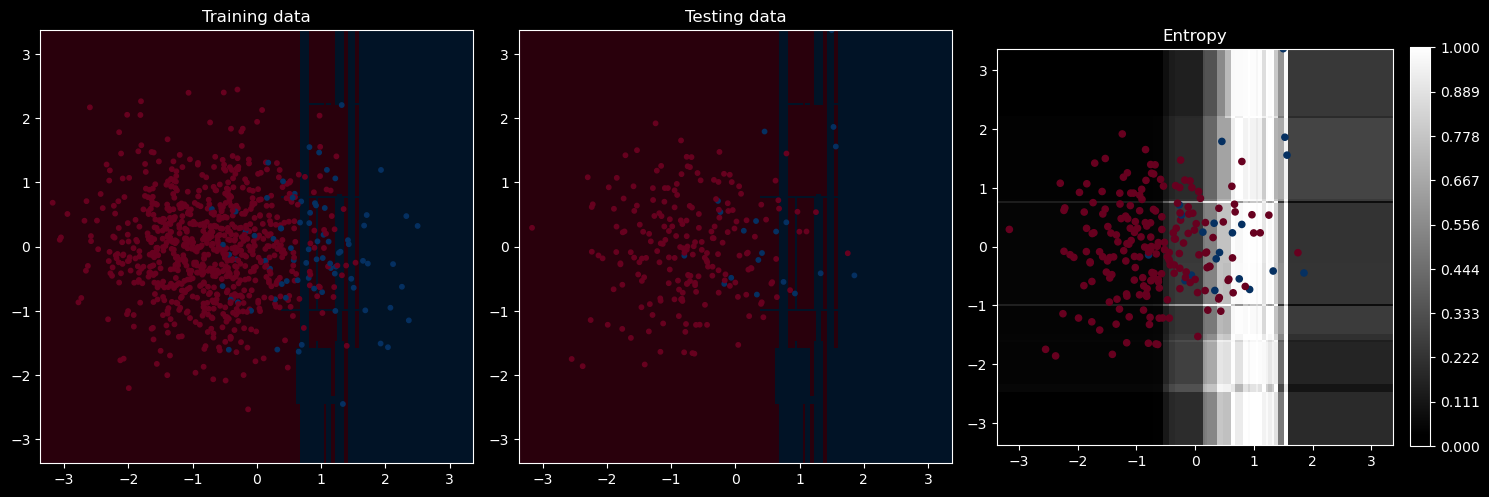

GradientBoostingClassifier(max_leaf_nodes=10)
              precision    recall  f1-score   support

           0       0.93      0.96      0.95       200
           1       0.42      0.25      0.31        20

    accuracy                           0.90       220
   macro avg       0.67      0.61      0.63       220
weighted avg       0.88      0.90      0.89       220



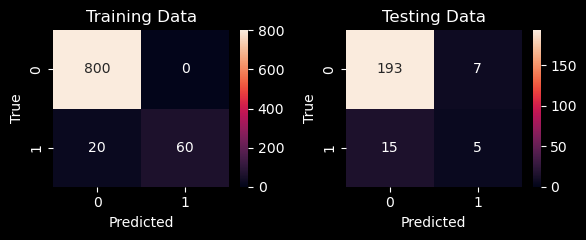

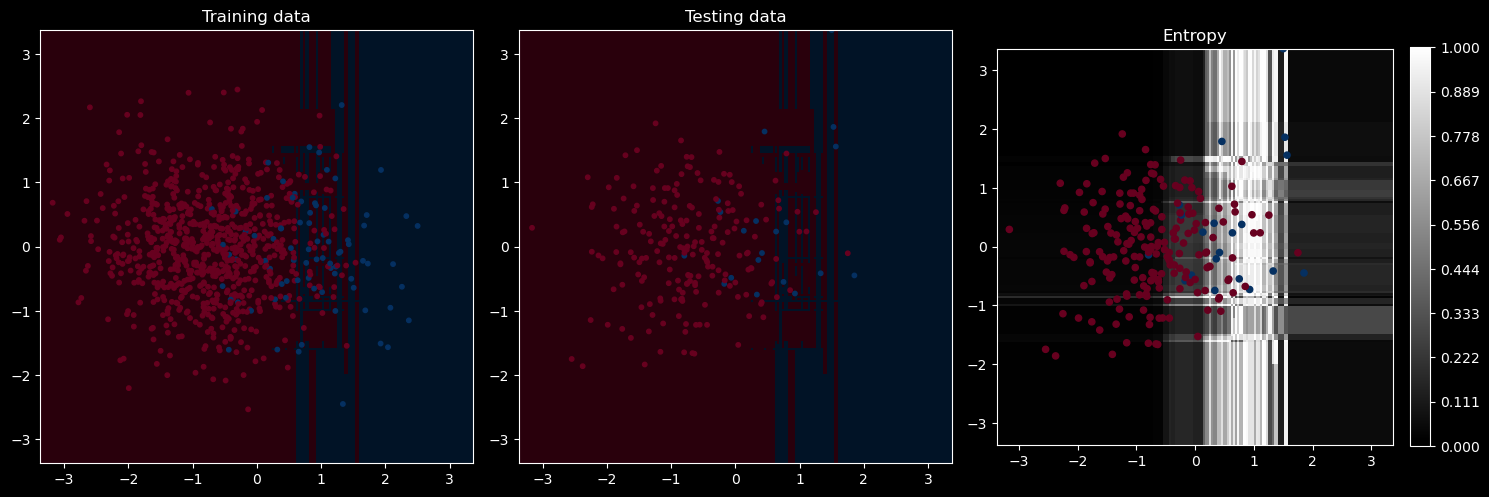

In [6]:
from sklearn.metrics import classification_report, confusion_matrix

for m in models:
    m.fit(X_train, y_train)
    y_train_pred = m.predict(X_train).astype(int)
    y_test_pred = m.predict(X_test).astype(int)
    
    print(m)
    print(classification_report(y_test, y_test_pred))
    
    conf_matrix_train = confusion_matrix(y_train, y_train_pred)
    conf_matrix_test = confusion_matrix(y_test, y_test_pred)
    
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(6, 2.5))
    
    sns.heatmap(conf_matrix_train, annot=True, vmin=0, fmt='d', ax=axes[0])
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("True")
    axes[0].set_title("Training Data")
    
    sns.heatmap(conf_matrix_test, annot=True, vmin=0, fmt='d', ax=axes[1])
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("True")
    axes[1].set_title("Testing Data")
    
    plt.tight_layout()
    plt.show()

    B, S = visualize_regions(m, MAX, 200)
    
    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15,5))
    
    extent = [-MAX,MAX,-MAX,MAX]
    
    cmap = "RdBu"
    axes[0].imshow(B, interpolation='none', extent=extent,cmap=cmap, alpha=0.4)
    axes[0].scatter(X_train[:,0], X_train[:,1], c=y_train, s=10, cmap=cmap);
    axes[0].set_aspect('equal')
    axes[0].set_title('Training data');
    
    axes[1].imshow(B, interpolation='none', extent=extent,cmap=cmap, alpha=0.4)
    axes[1].scatter(X_test[:,0], X_test[:,1], c=y_test, s=10, cmap=cmap);
    axes[1].set_aspect('equal')
    axes[1].set_title('Testing data');
    
    im = axes[2].imshow(S, interpolation='none', extent=extent,cmap='gray')
    axes[2].scatter(X_test[:,0], X_test[:,1], c=y_test, s=20, cmap=cmap);
    axes[2].set_aspect('equal')
    axes[2].set_title('Entropy')
    cbar = fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
    cbar.set_ticks(np.linspace(0, math.log(y.max()+1,2), 10))

    plt.tight_layout()
    plt.show()
# end

## 4. Modeling with manual balancing

The fix, written out explicitly before reaching for a library.

For each class, `np.random.choice` draws `n_resamp = 1000` indices **with replacement** from that
class's training rows, so both classes end up at exactly 1,000. Class 0 has ~800 training rows, so
it is sampled roughly at its own size; class 1 has ~80, so each of those points is duplicated about
12 times over.

That duplication is the cost. No new information is created — the same 80 points are repeated — so
a flexible model can memorize them, and the minority region of the decision map may end up drawn
tightly around a handful of locations. Section 5 of `U1-7_Imbalance-3_SMOTE` addresses exactly this
by synthesizing new points instead of copying old ones.

**Resample the training set only.** The test set must keep the real 10:1 ratio, or the reported
performance describes a world that does not exist. Note that the split happens *before* the
resampling here, which is what makes that true.

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
)

In [8]:
n_resamp = 1000

idx_train_0 = np.where(y_train==0)[0]
idx_train_1 = np.where(y_train==1)[0]

idx_train_0 = np.random.choice(idx_train_0, n_resamp)
idx_train_1 = np.random.choice(idx_train_1, n_resamp)

X_train_bal = np.concatenate(
    ( X_train[idx_train_0,:], X_train[idx_train_1,:] ),
    axis=0
)

y_train_bal = np.concatenate(
    ( y_train[idx_train_0], y_train[idx_train_1] ),
    axis=0
)

print("Original data:")
print(pd.Series(y).value_counts())
print()
print("Training data:")
print(pd.Series(y_train_bal).value_counts())
print()
print("Testing data:")
print(pd.Series(y_test).value_counts())

Original data:
0    1000
1     100
Name: count, dtype: int64

Training data:
0    1000
1    1000
Name: count, dtype: int64

Testing data:
0    200
1     20
Name: count, dtype: int64


Now compare the classification reports against section 3. Expect recall on class 1 to rise sharply
and precision on class 1 to fall — the model now predicts the minority class more freely, catching
more of them and also flagging more false positives. Whether that trade is worth it is a question
about the application, not about the metric, and `U1-7_Imbalance-4_ClassWeights` makes it explicit
with a reward matrix.

LogisticRegression()
              precision    recall  f1-score   support

           0       0.99      0.81      0.89       200
           1       0.33      0.90      0.48        20

    accuracy                           0.82       220
   macro avg       0.66      0.86      0.69       220
weighted avg       0.93      0.82      0.86       220



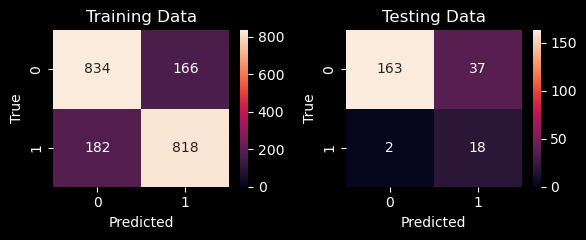

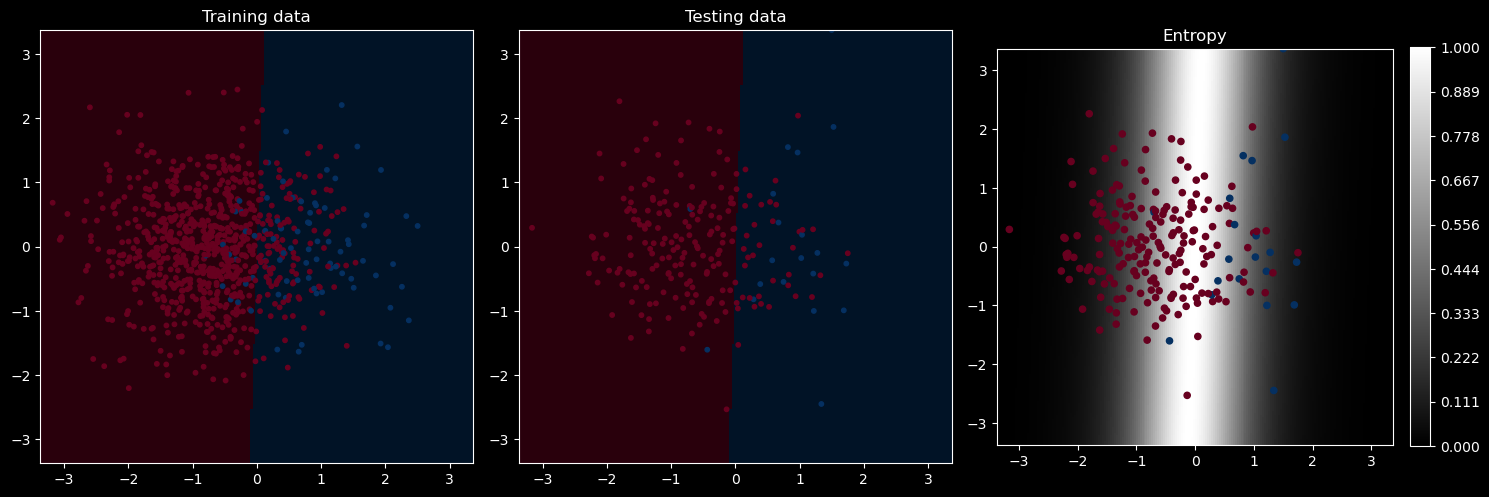

KNeighborsClassifier(n_neighbors=1)
              precision    recall  f1-score   support

           0       0.95      0.91      0.93       200
           1       0.36      0.50      0.42        20

    accuracy                           0.87       220
   macro avg       0.65      0.71      0.67       220
weighted avg       0.89      0.87      0.88       220



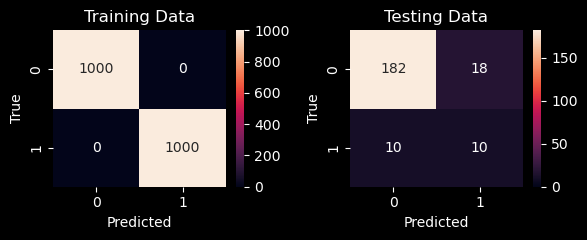

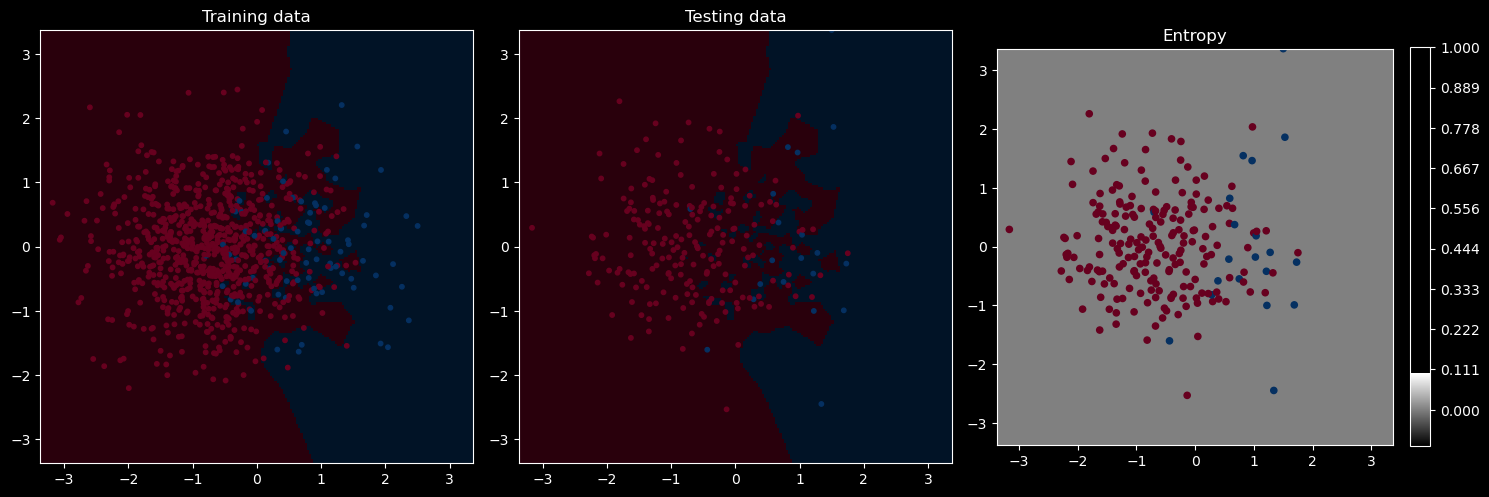

KNeighborsClassifier()
              precision    recall  f1-score   support

           0       0.97      0.83      0.90       200
           1       0.31      0.75      0.44        20

    accuracy                           0.83       220
   macro avg       0.64      0.79      0.67       220
weighted avg       0.91      0.83      0.86       220



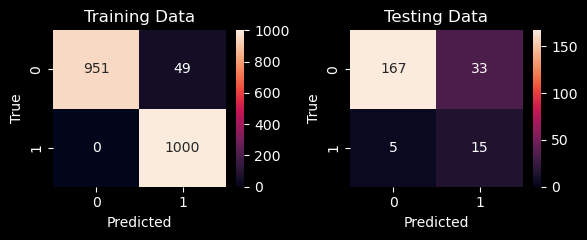

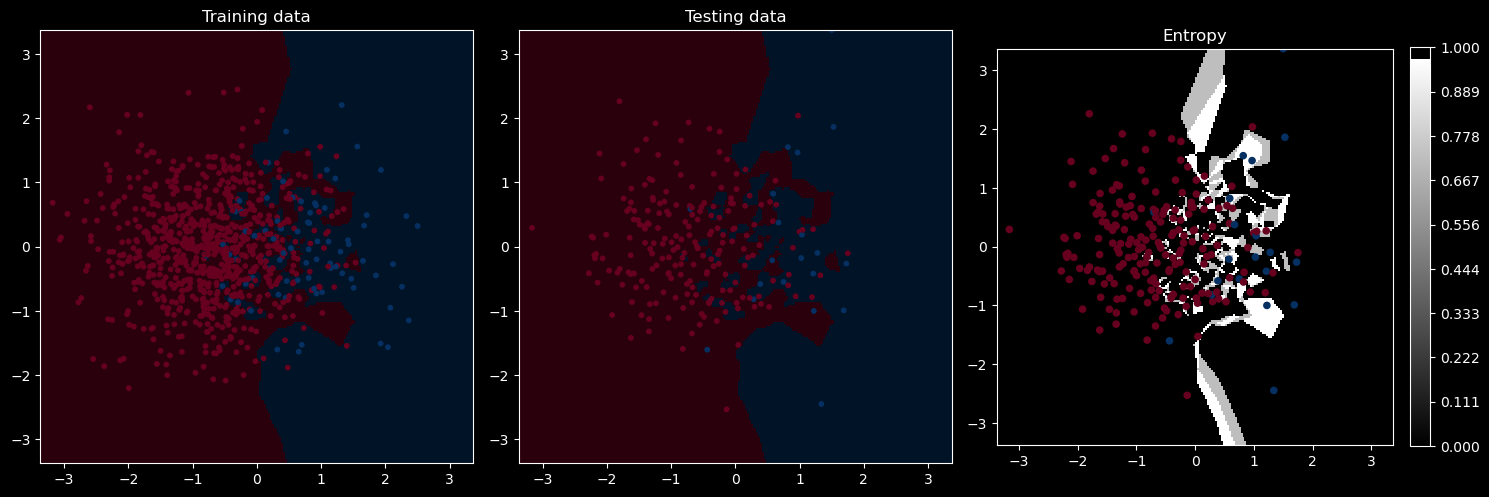

KNeighborsClassifier(n_neighbors=10)
              precision    recall  f1-score   support

           0       0.98      0.79      0.87       200
           1       0.28      0.85      0.42        20

    accuracy                           0.79       220
   macro avg       0.63      0.82      0.65       220
weighted avg       0.92      0.79      0.83       220



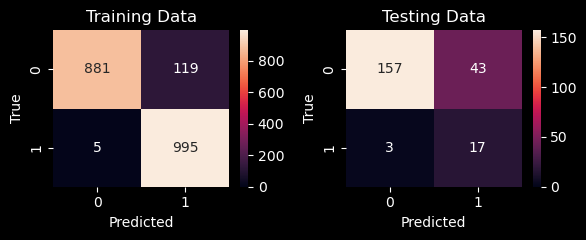

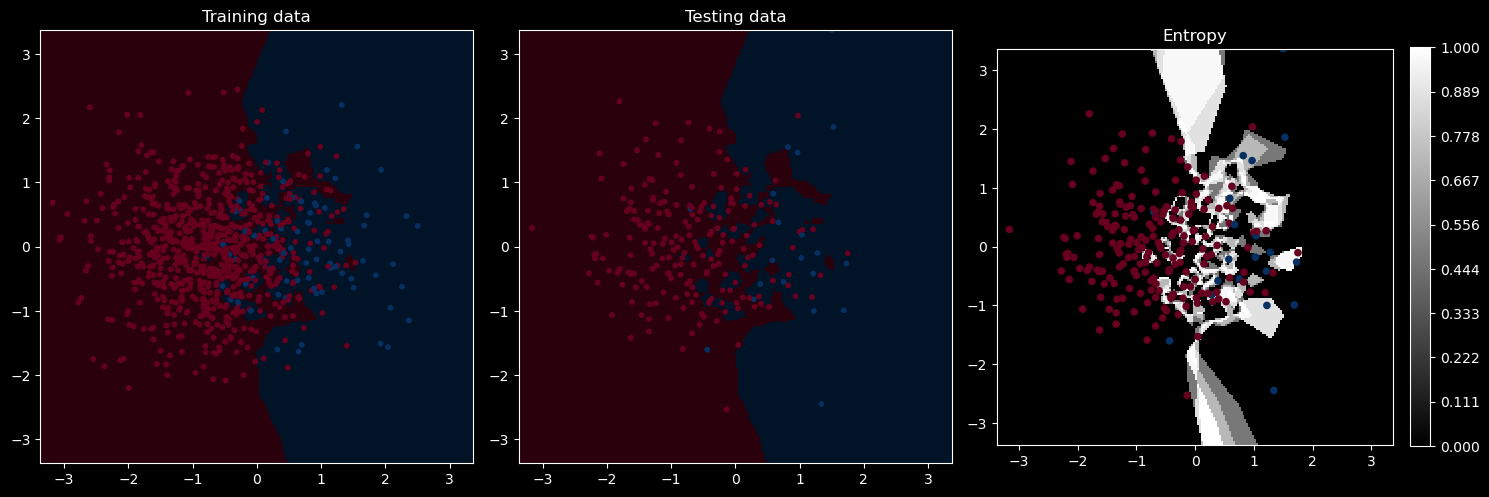

KNeighborsClassifier(n_neighbors=50)
              precision    recall  f1-score   support

           0       0.99      0.72      0.84       200
           1       0.25      0.90      0.39        20

    accuracy                           0.74       220
   macro avg       0.62      0.81      0.61       220
weighted avg       0.92      0.74      0.79       220



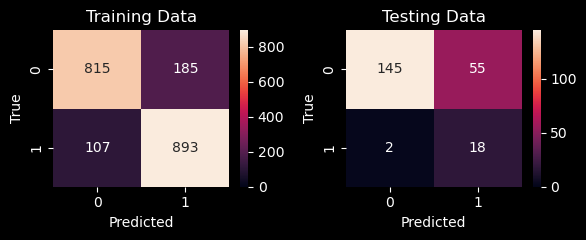

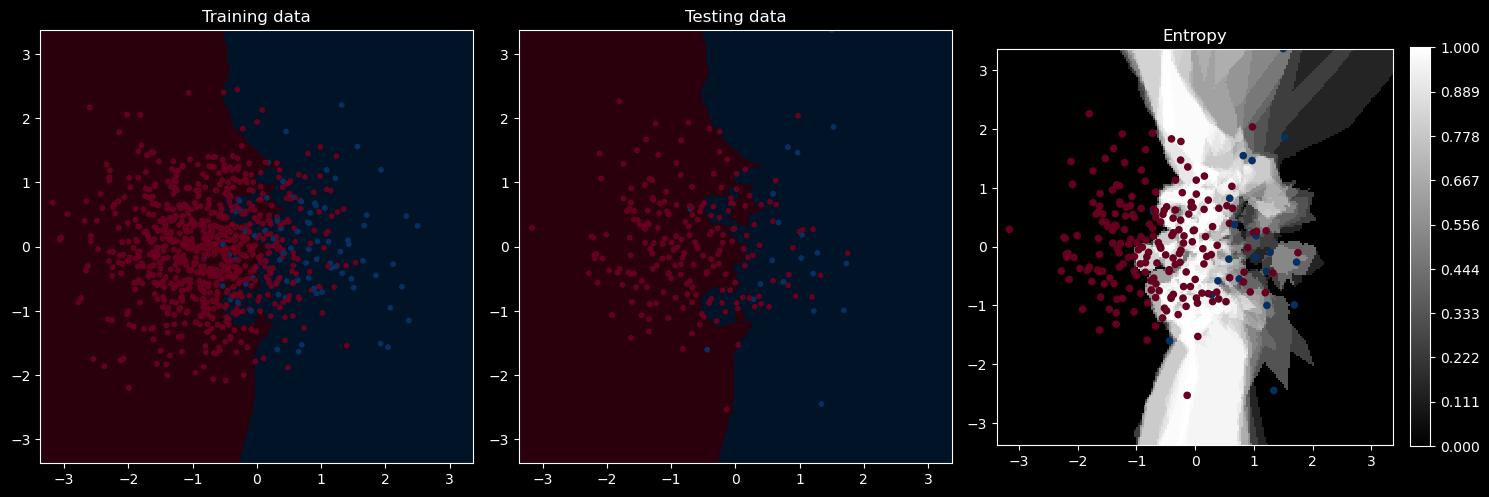

RandomForestClassifier(max_leaf_nodes=3, n_estimators=10)
              precision    recall  f1-score   support

           0       0.99      0.69      0.81       200
           1       0.22      0.90      0.36        20

    accuracy                           0.70       220
   macro avg       0.60      0.79      0.58       220
weighted avg       0.92      0.70      0.77       220



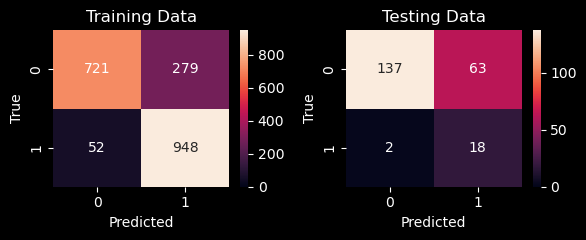

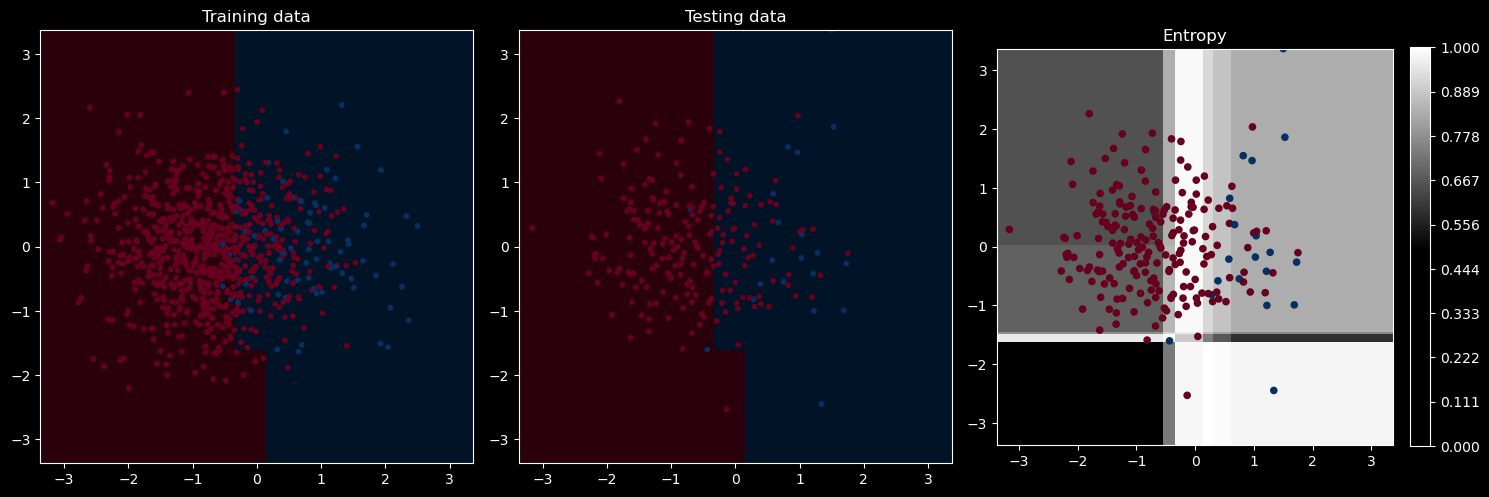

RandomForestClassifier(max_leaf_nodes=10, n_estimators=10)
              precision    recall  f1-score   support

           0       0.99      0.80      0.88       200
           1       0.31      0.90      0.46        20

    accuracy                           0.80       220
   macro avg       0.65      0.85      0.67       220
weighted avg       0.93      0.80      0.84       220



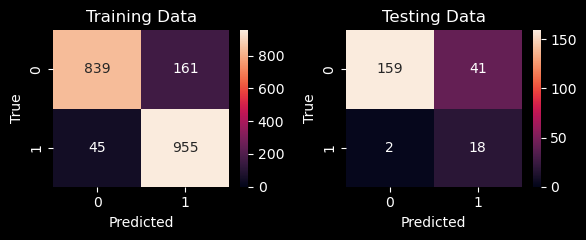

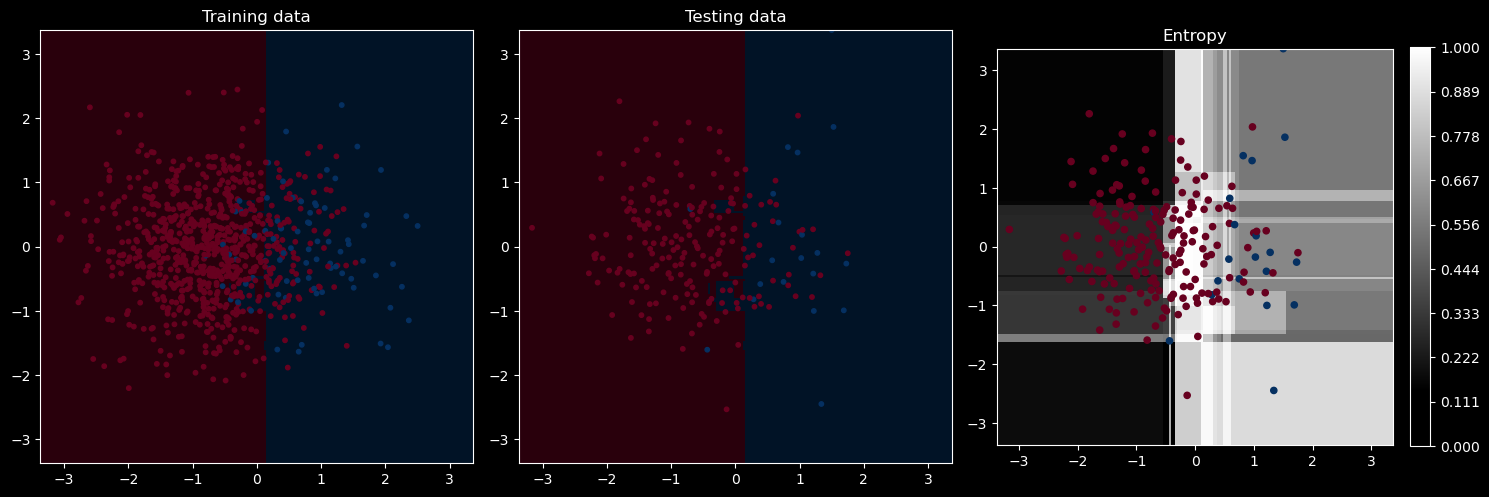

RandomForestClassifier(max_leaf_nodes=3)
              precision    recall  f1-score   support

           0       0.99      0.83      0.91       200
           1       0.35      0.90      0.51        20

    accuracy                           0.84       220
   macro avg       0.67      0.87      0.71       220
weighted avg       0.93      0.84      0.87       220



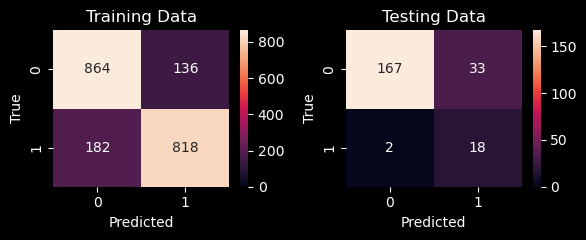

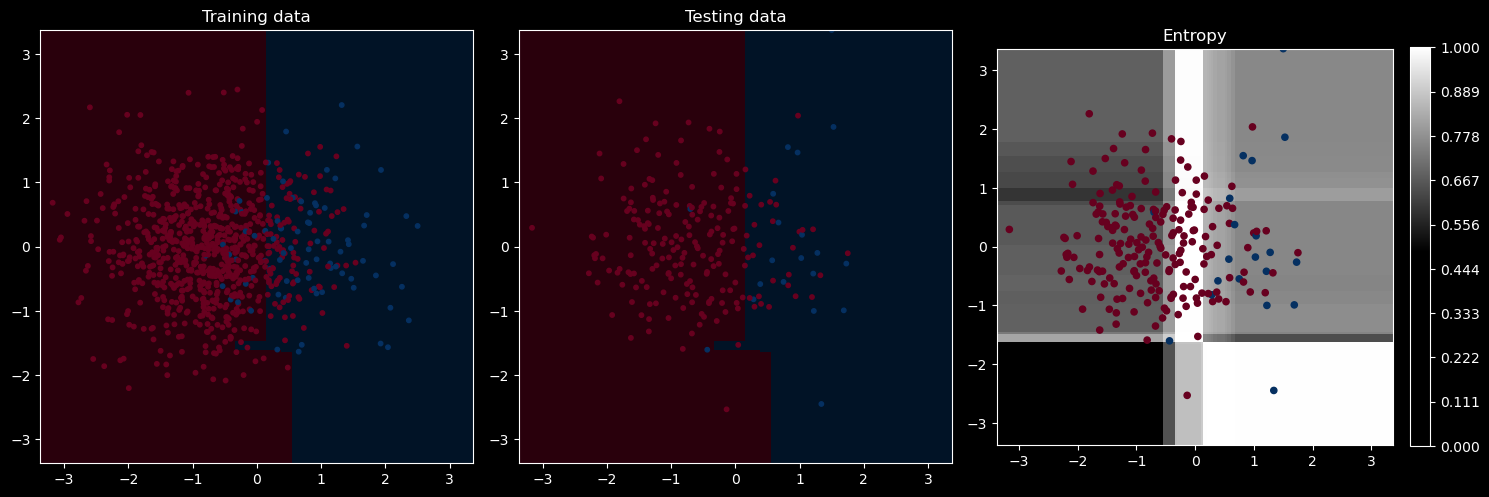

RandomForestClassifier(max_leaf_nodes=10)
              precision    recall  f1-score   support

           0       0.99      0.80      0.88       200
           1       0.31      0.90      0.46        20

    accuracy                           0.81       220
   macro avg       0.65      0.85      0.67       220
weighted avg       0.93      0.81      0.85       220



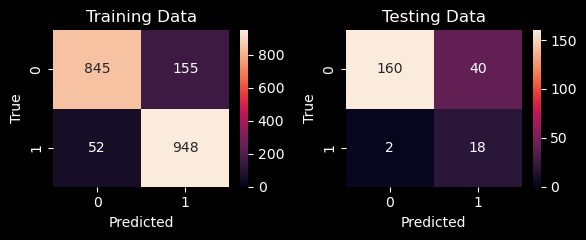

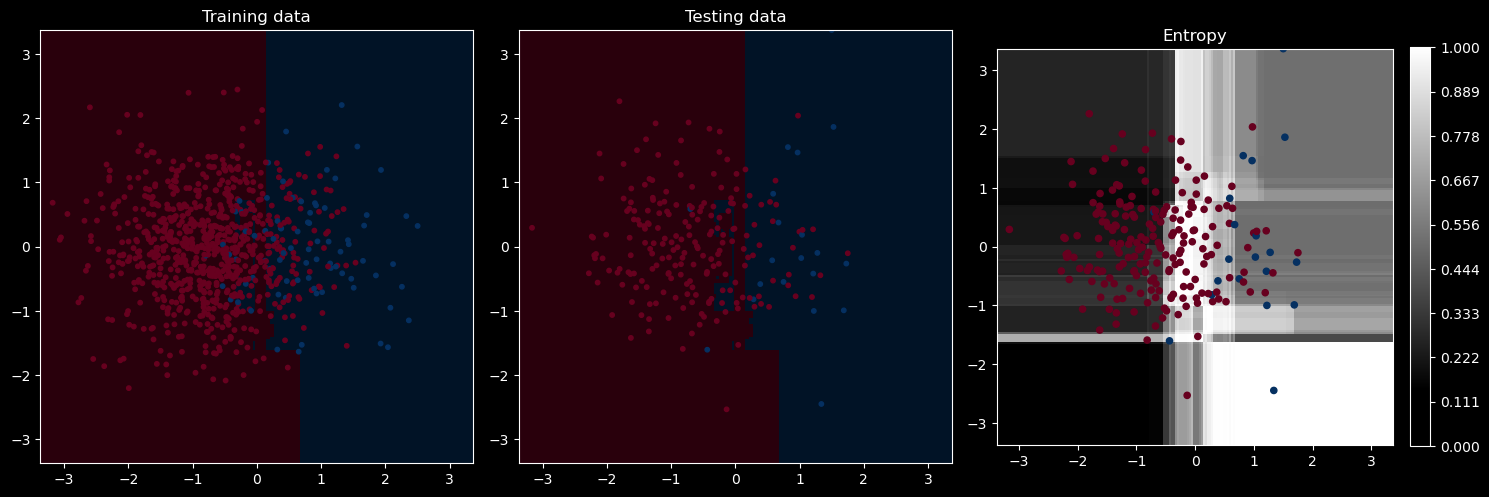

RandomForestClassifier(max_leaf_nodes=30)
              precision    recall  f1-score   support

           0       0.98      0.84      0.91       200
           1       0.34      0.80      0.48        20

    accuracy                           0.84       220
   macro avg       0.66      0.82      0.69       220
weighted avg       0.92      0.84      0.87       220



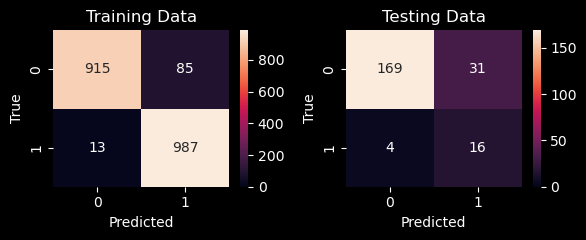

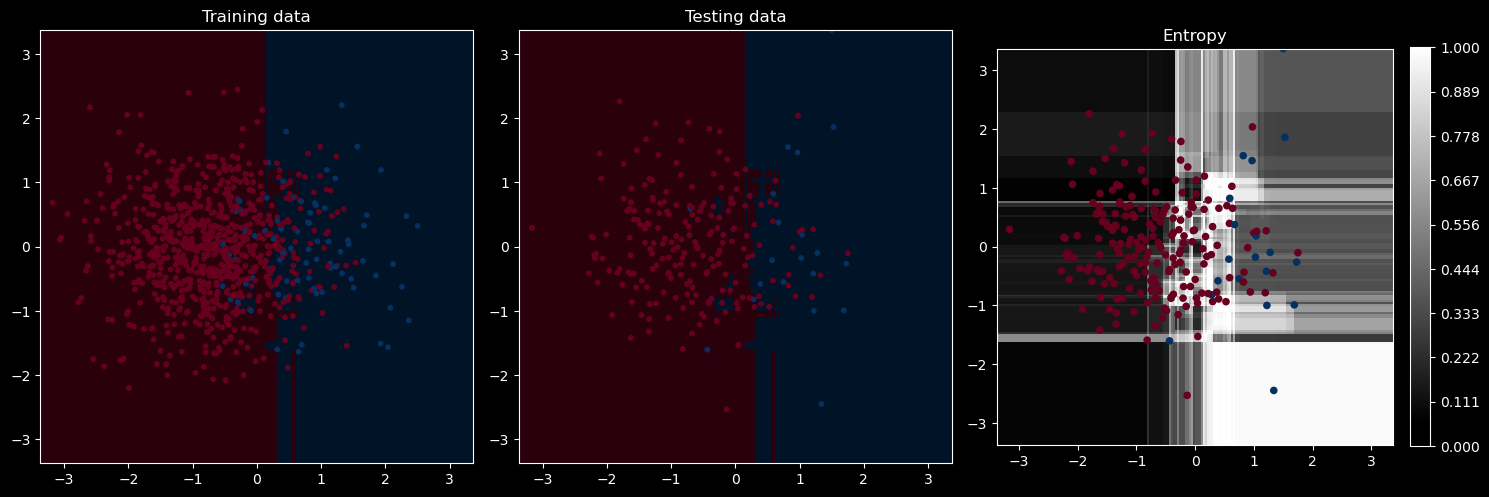

GradientBoostingClassifier(max_leaf_nodes=3, n_estimators=10)
              precision    recall  f1-score   support

           0       0.99      0.84      0.91       200
           1       0.36      0.90      0.51        20

    accuracy                           0.85       220
   macro avg       0.67      0.87      0.71       220
weighted avg       0.93      0.85      0.87       220



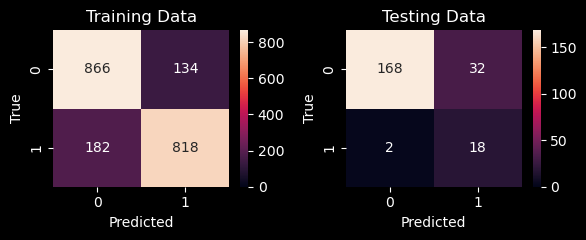

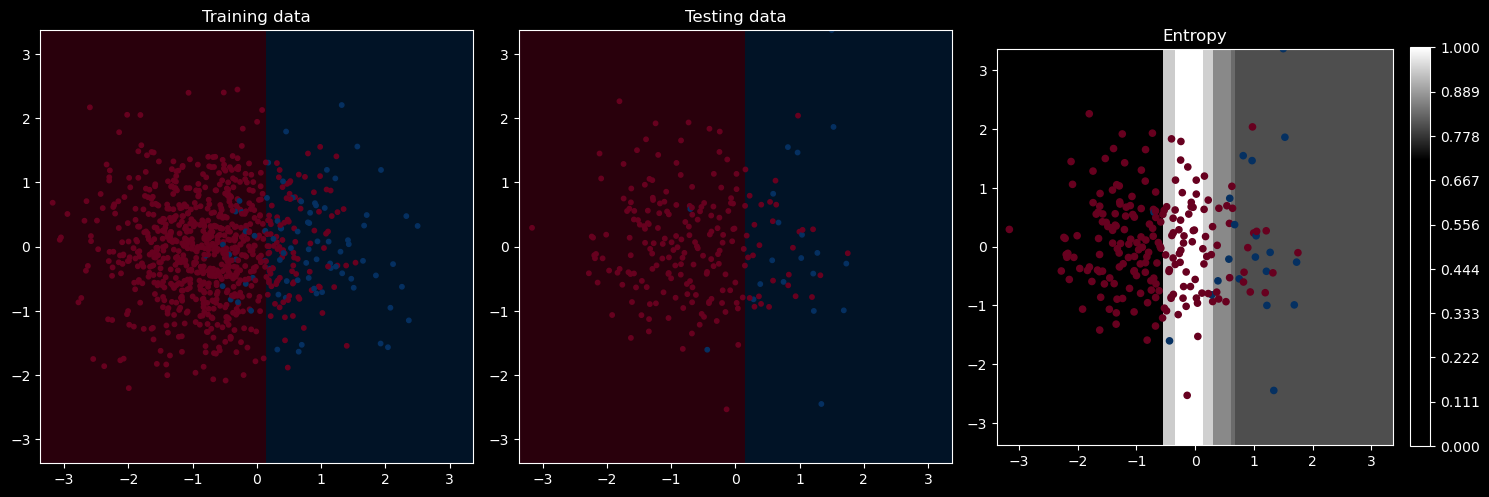

GradientBoostingClassifier(max_leaf_nodes=10, n_estimators=10)
              precision    recall  f1-score   support

           0       0.99      0.81      0.89       200
           1       0.32      0.90      0.47        20

    accuracy                           0.82       220
   macro avg       0.65      0.85      0.68       220
weighted avg       0.93      0.82      0.85       220



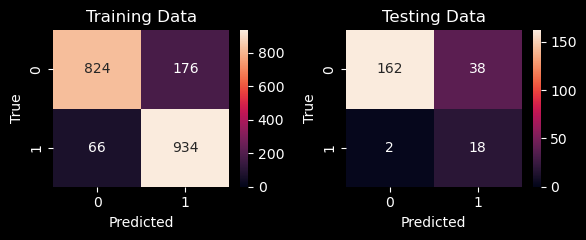

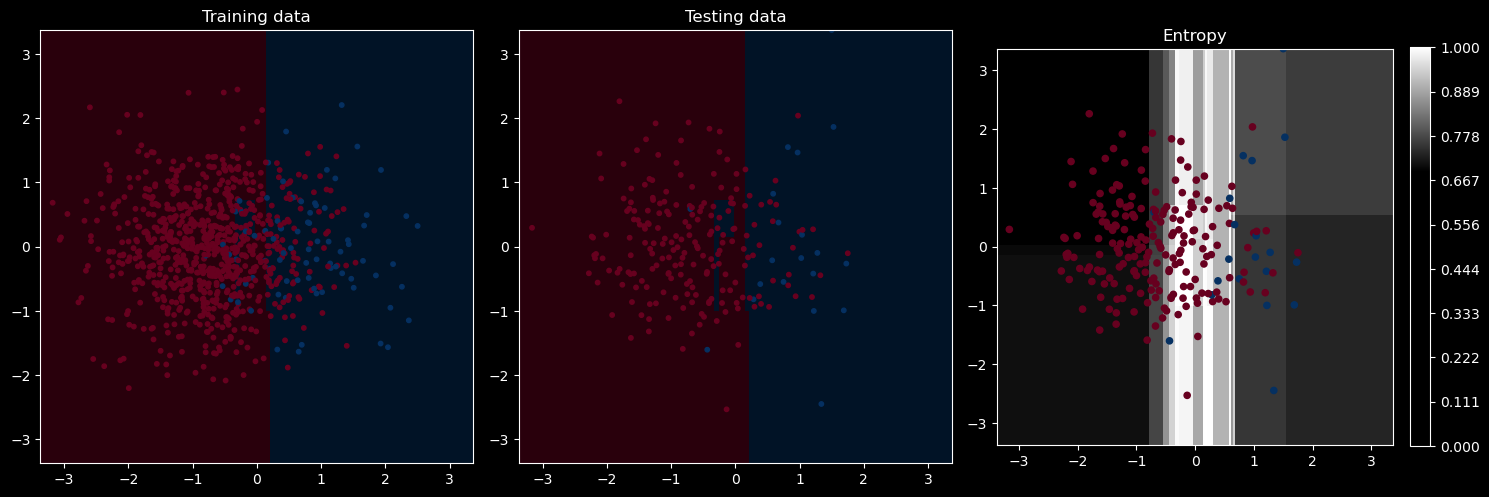

GradientBoostingClassifier(max_leaf_nodes=3)
              precision    recall  f1-score   support

           0       0.98      0.86      0.91       200
           1       0.36      0.80      0.50        20

    accuracy                           0.85       220
   macro avg       0.67      0.83      0.71       220
weighted avg       0.92      0.85      0.88       220



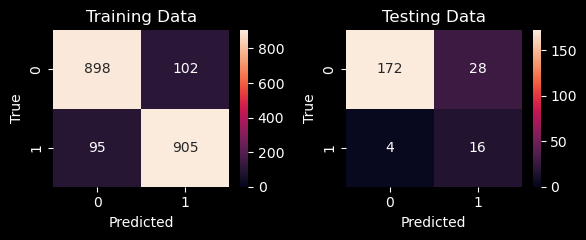

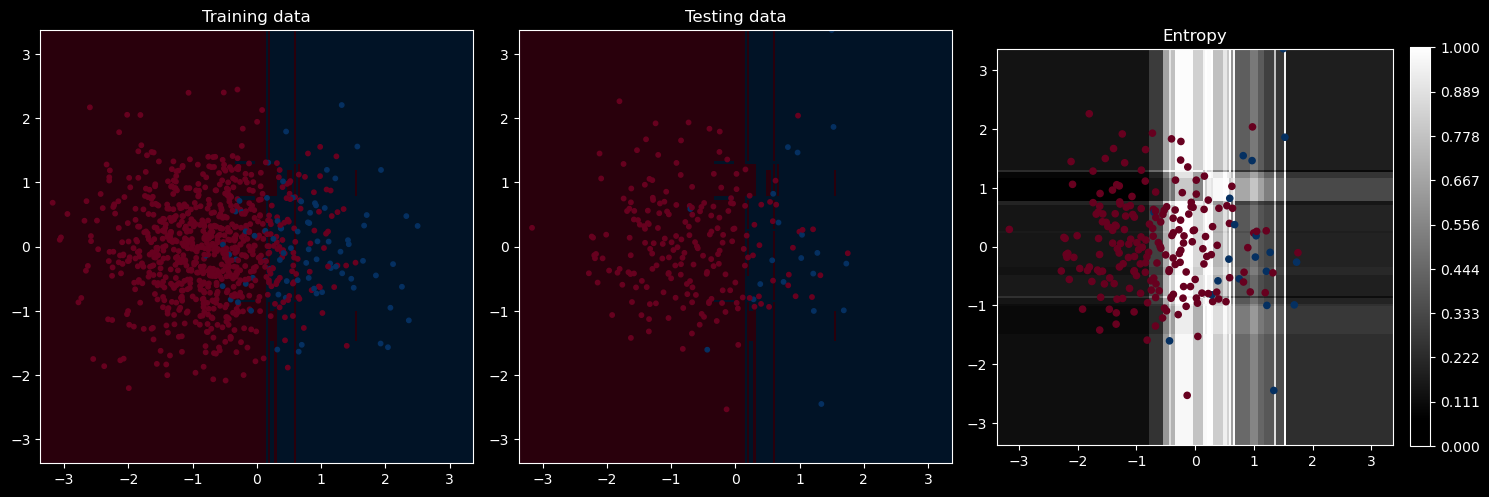

GradientBoostingClassifier(max_leaf_nodes=10)
              precision    recall  f1-score   support

           0       0.97      0.85      0.90       200
           1       0.32      0.70      0.44        20

    accuracy                           0.84       220
   macro avg       0.64      0.77      0.67       220
weighted avg       0.91      0.84      0.86       220



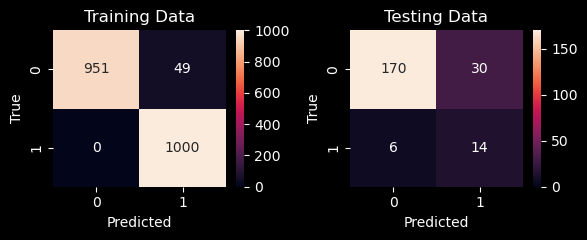

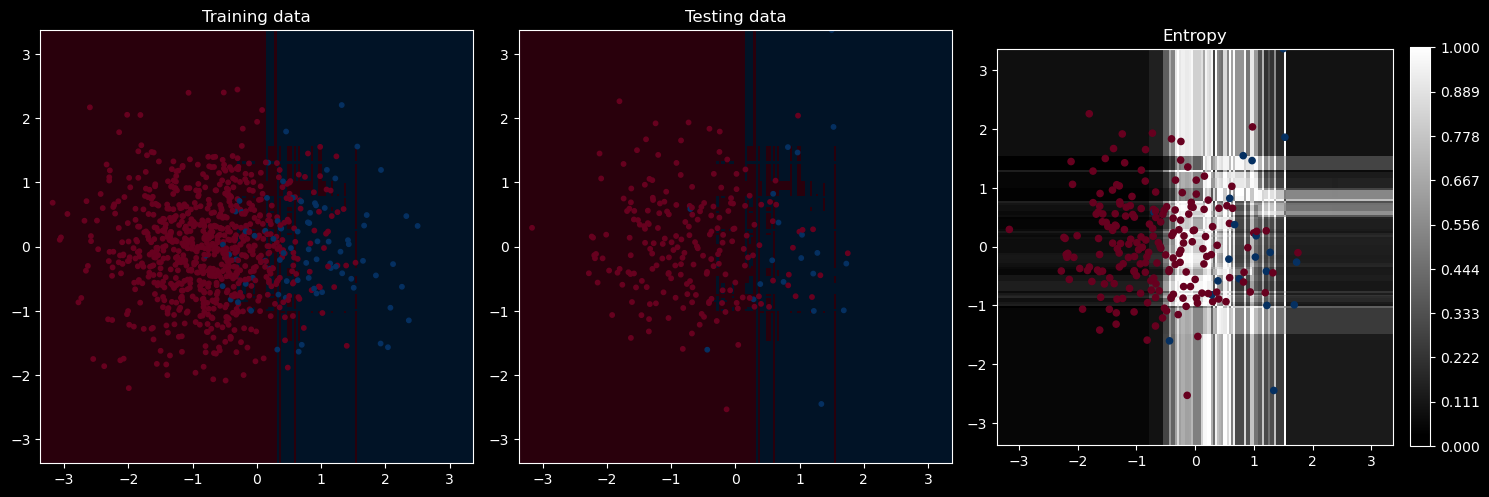

In [9]:
from sklearn.metrics import classification_report, confusion_matrix

for m in models:
    m.fit(X_train_bal, y_train_bal)
    y_train_bal_pred = m.predict(X_train_bal).astype(int)
    y_test_bal_pred = m.predict(X_test).astype(int)
    
    print(m)
    print(classification_report(y_test, y_test_bal_pred))
    
    conf_matrix_train = confusion_matrix(y_train_bal, y_train_bal_pred)
    conf_matrix_test = confusion_matrix(y_test, y_test_bal_pred)
    
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(6, 2.5))
    
    sns.heatmap(conf_matrix_train, annot=True, vmin=0, fmt='d', ax=axes[0])
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("True")
    axes[0].set_title("Training Data")
    
    sns.heatmap(conf_matrix_test, annot=True, vmin=0, fmt='d', ax=axes[1])
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("True")
    axes[1].set_title("Testing Data")
    
    plt.tight_layout()
    plt.show()

    B, S = visualize_regions(m, MAX, 200)
    
    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15,5))
    
    extent = [-MAX,MAX,-MAX,MAX]
    
    cmap = "RdBu"
    axes[0].imshow(B, interpolation='none', extent=extent,cmap=cmap, alpha=0.4)
    axes[0].scatter(X_train[:,0], X_train[:,1], c=y_train, s=10, cmap=cmap);
    axes[0].set_aspect('equal')
    axes[0].set_title('Training data');
    
    axes[1].imshow(B, interpolation='none', extent=extent,cmap=cmap, alpha=0.4)
    axes[1].scatter(X_test[:,0], X_test[:,1], c=y_test, s=10, cmap=cmap);
    axes[1].set_aspect('equal')
    axes[1].set_title('Testing data');
    
    im = axes[2].imshow(S, interpolation='none', extent=extent,cmap='gray')
    axes[2].scatter(X_test[:,0], X_test[:,1], c=y_test, s=20, cmap=cmap);
    axes[2].set_aspect('equal')
    axes[2].set_title('Entropy')
    cbar = fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
    cbar.set_ticks(np.linspace(0, math.log(y.max()+1,2), 10))

    plt.tight_layout()
    plt.show()
# end

## 5. Modeling with `imblearn`

`RandomOverSampler` does exactly what section 4 did by hand: sample the minority class with
replacement until the classes match. One call replaces the index arithmetic.

`imbalanced-learn` follows scikit-learn's API conventions, so `fit_resample` mirrors
`fit_transform`, and its samplers drop into pipelines.

In [10]:
#!pip install imbalanced-learn

In [11]:
from imblearn.over_sampling import RandomOverSampler
from collections import Counter

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y
)

# Apply random oversampling
ros = RandomOverSampler()

X_train_res, y_train_res = ros.fit_resample(X_train, y_train)

print("Original data:")
print(pd.Series(y).value_counts())
print()
print("Training data:")
print(pd.Series(y_train_res).value_counts())
print()
print("Testing data:")
print(pd.Series(y_test).value_counts())

Original data:
0    1000
1     100
Name: count, dtype: int64

Training data:
0    800
1    800
Name: count, dtype: int64

Testing data:
0    200
1     20
Name: count, dtype: int64


The evaluation below uses `X_train_res` / `y_train_res` — the `RandomOverSampler` output from the
cell above — so this section reports on the library's resampling rather than on section 4's manual
version. The two approaches should land in the same place, which is the point: the library is a
convenience, not a different method.

LogisticRegression()
              precision    recall  f1-score   support

           0       0.98      0.83      0.90       200
           1       0.34      0.85      0.49        20

    accuracy                           0.84       220
   macro avg       0.66      0.84      0.69       220
weighted avg       0.92      0.84      0.86       220



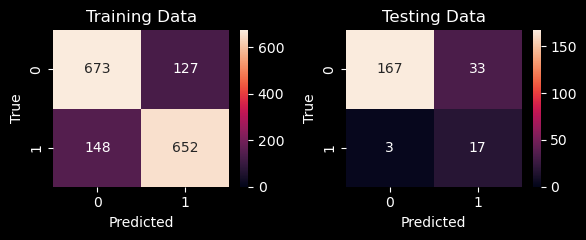

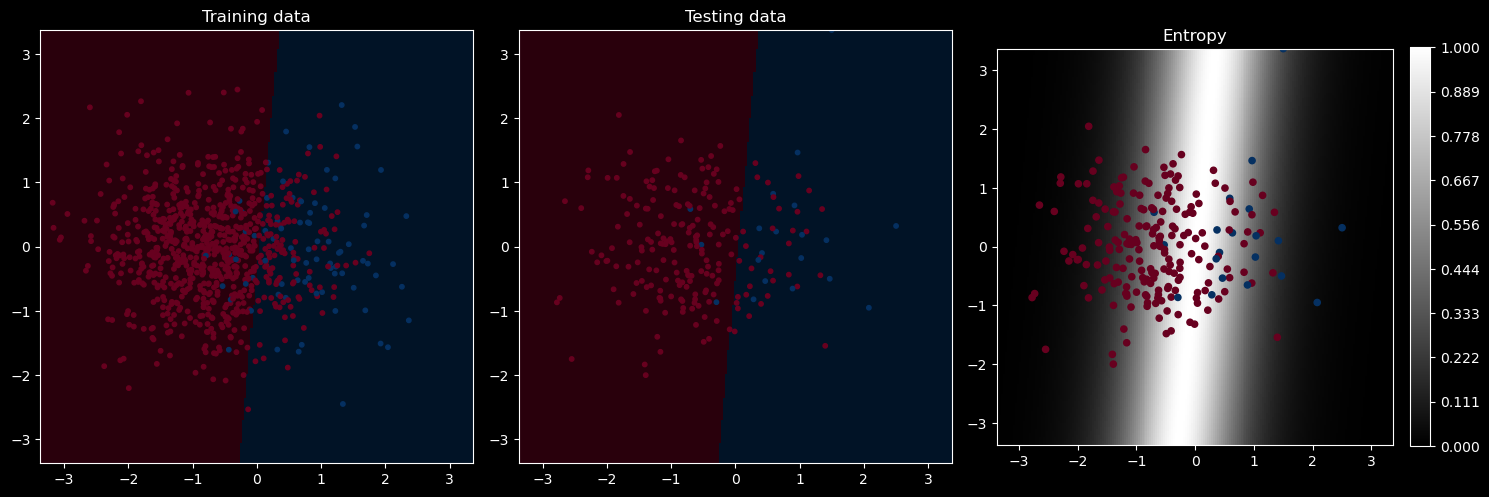

KNeighborsClassifier(n_neighbors=1)
              precision    recall  f1-score   support

           0       0.95      0.95      0.95       200
           1       0.55      0.55      0.55        20

    accuracy                           0.92       220
   macro avg       0.75      0.75      0.75       220
weighted avg       0.92      0.92      0.92       220



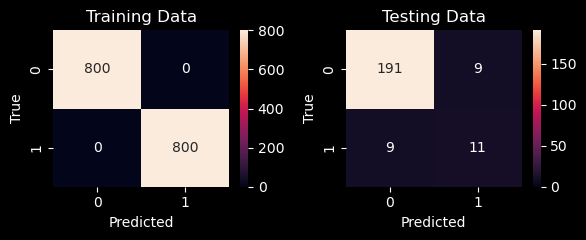

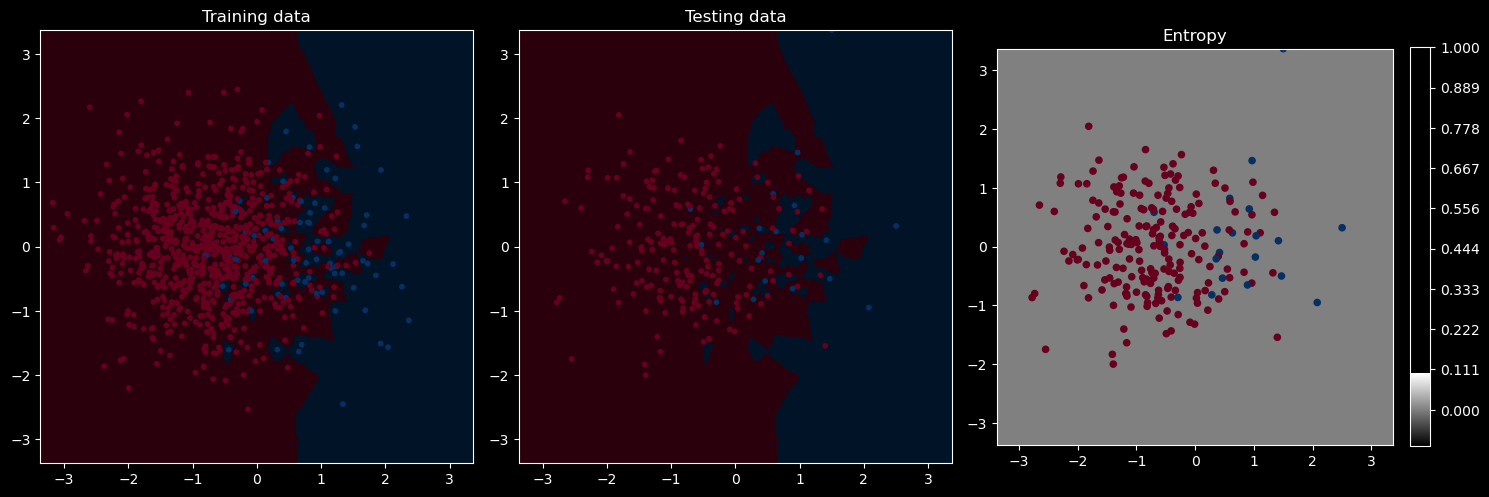

KNeighborsClassifier()
              precision    recall  f1-score   support

           0       0.97      0.83      0.90       200
           1       0.30      0.70      0.42        20

    accuracy                           0.82       220
   macro avg       0.63      0.77      0.66       220
weighted avg       0.90      0.82      0.85       220



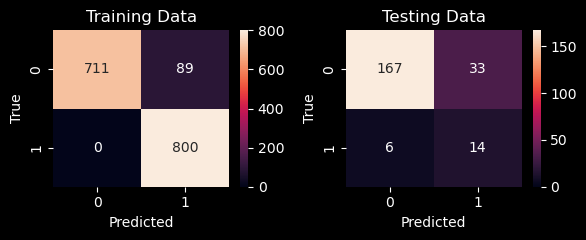

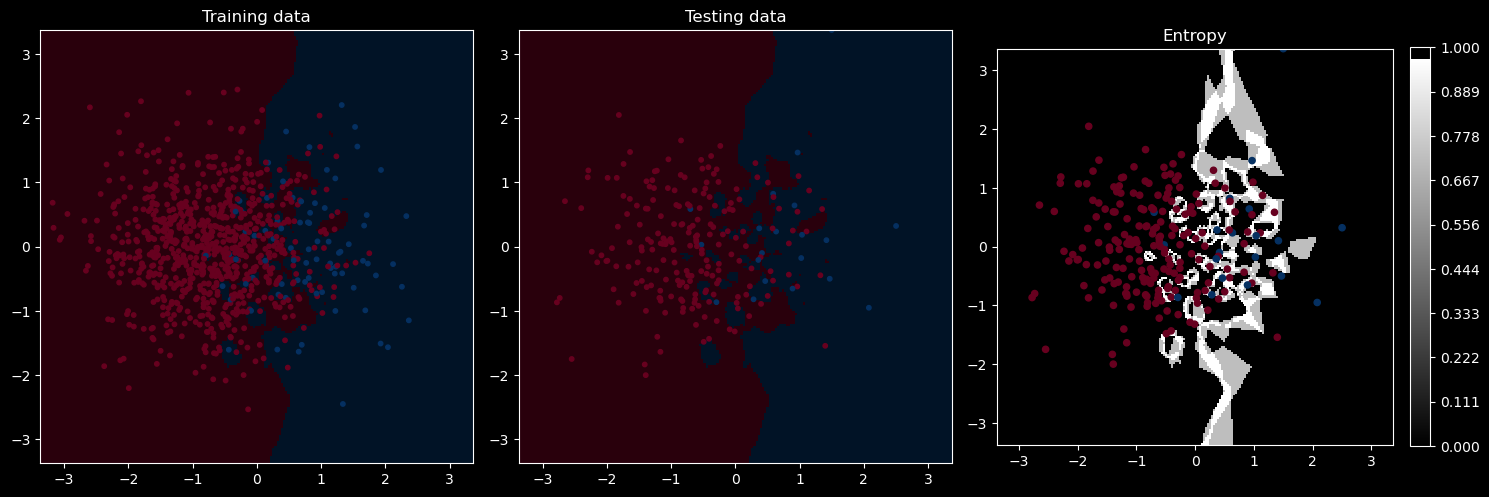

KNeighborsClassifier(n_neighbors=10)
              precision    recall  f1-score   support

           0       0.97      0.81      0.88       200
           1       0.28      0.75      0.41        20

    accuracy                           0.80       220
   macro avg       0.62      0.78      0.64       220
weighted avg       0.91      0.80      0.84       220



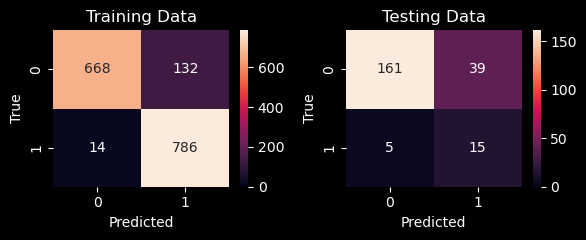

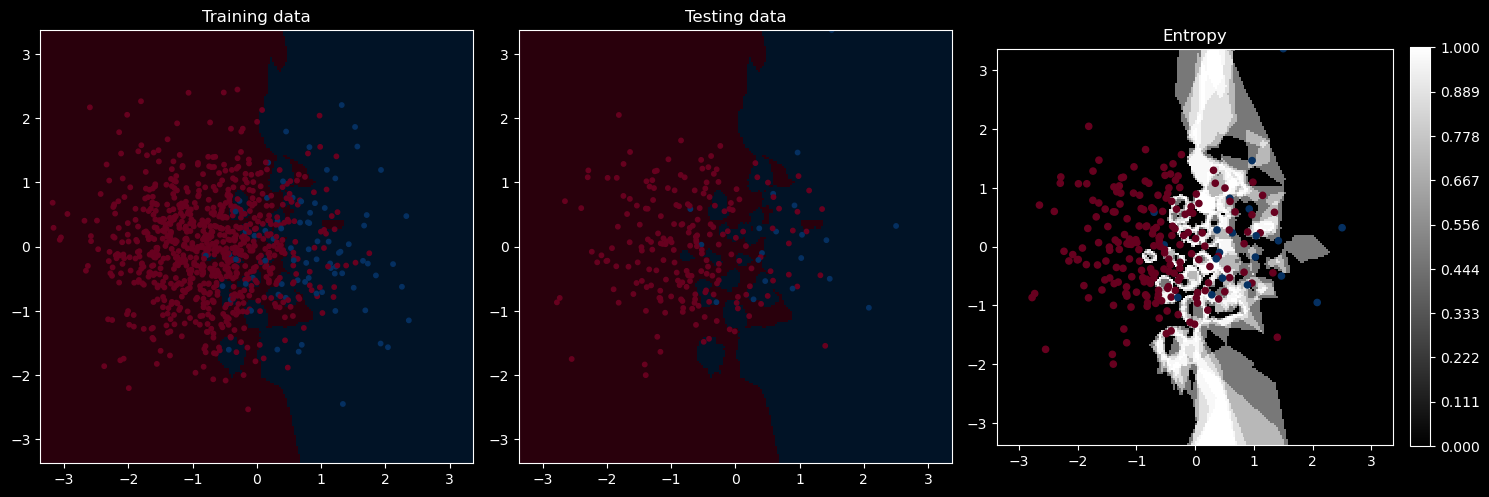

KNeighborsClassifier(n_neighbors=50)
              precision    recall  f1-score   support

           0       0.98      0.80      0.88       200
           1       0.30      0.85      0.44        20

    accuracy                           0.80       220
   macro avg       0.64      0.82      0.66       220
weighted avg       0.92      0.80      0.84       220



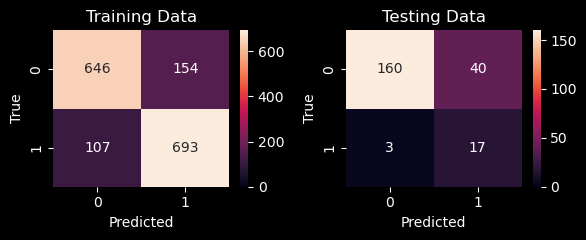

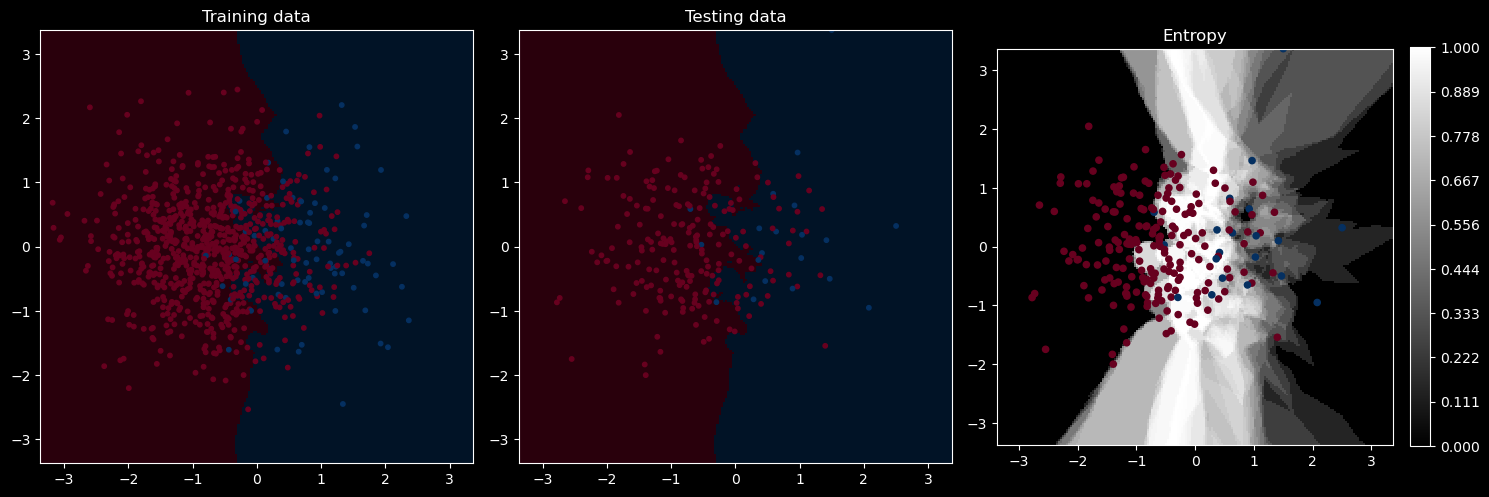

RandomForestClassifier(max_leaf_nodes=3, n_estimators=10)
              precision    recall  f1-score   support

           0       0.99      0.72      0.84       200
           1       0.25      0.90      0.39        20

    accuracy                           0.74       220
   macro avg       0.62      0.81      0.61       220
weighted avg       0.92      0.74      0.79       220



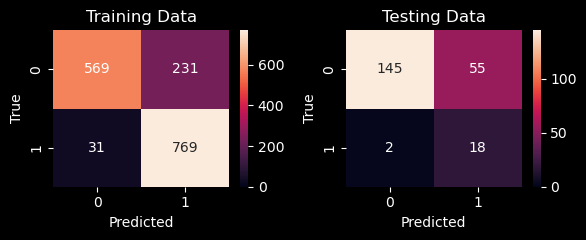

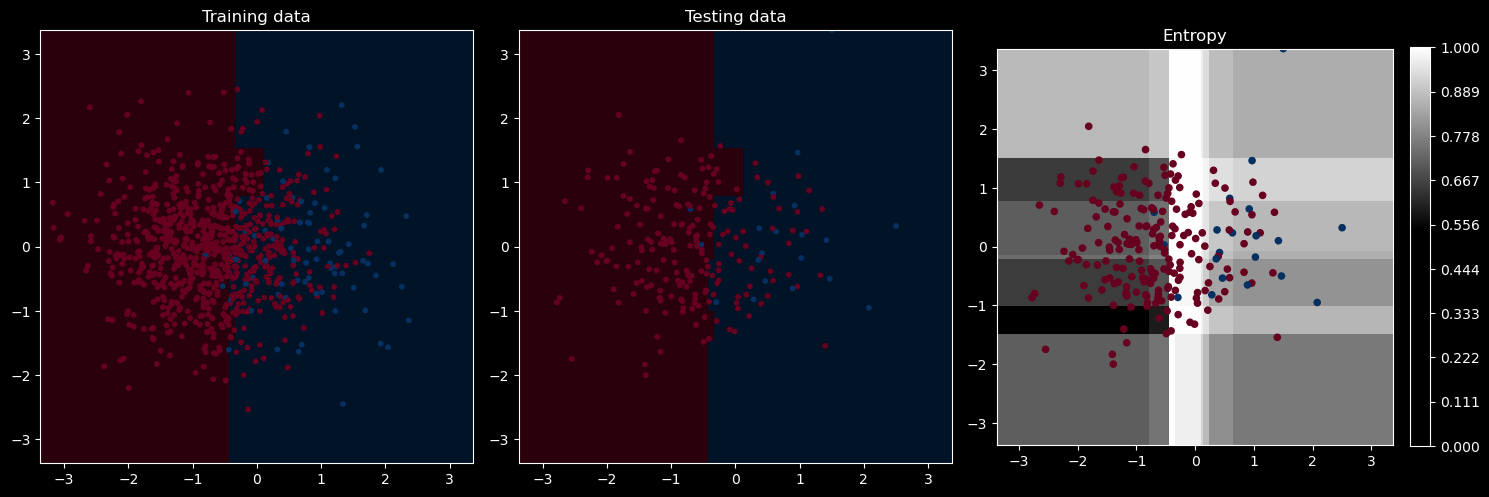

RandomForestClassifier(max_leaf_nodes=10, n_estimators=10)
              precision    recall  f1-score   support

           0       0.98      0.85      0.91       200
           1       0.36      0.85      0.51        20

    accuracy                           0.85       220
   macro avg       0.67      0.85      0.71       220
weighted avg       0.93      0.85      0.87       220



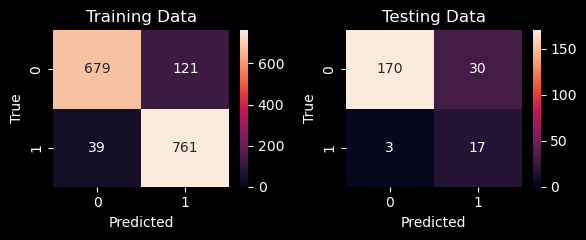

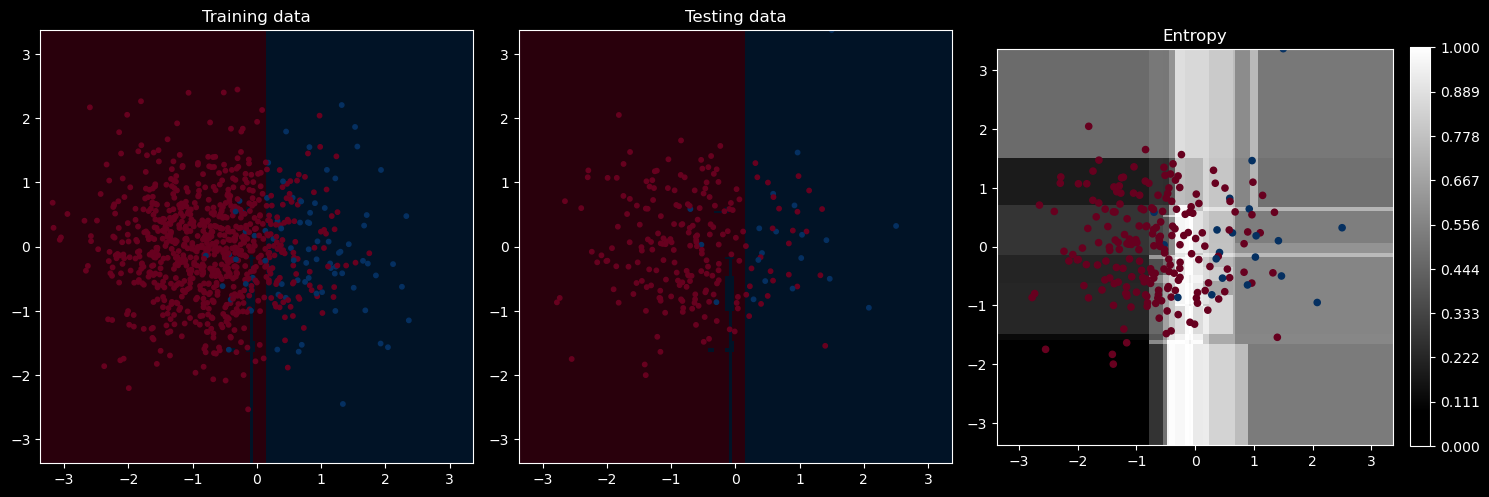

RandomForestClassifier(max_leaf_nodes=3)
              precision    recall  f1-score   support

           0       0.98      0.86      0.92       200
           1       0.39      0.85      0.53        20

    accuracy                           0.86       220
   macro avg       0.68      0.86      0.73       220
weighted avg       0.93      0.86      0.88       220



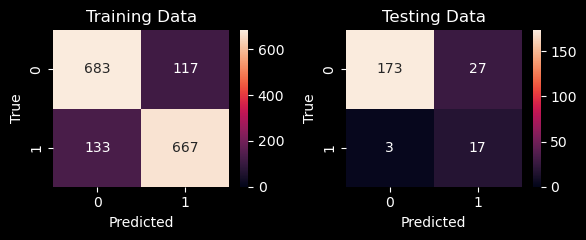

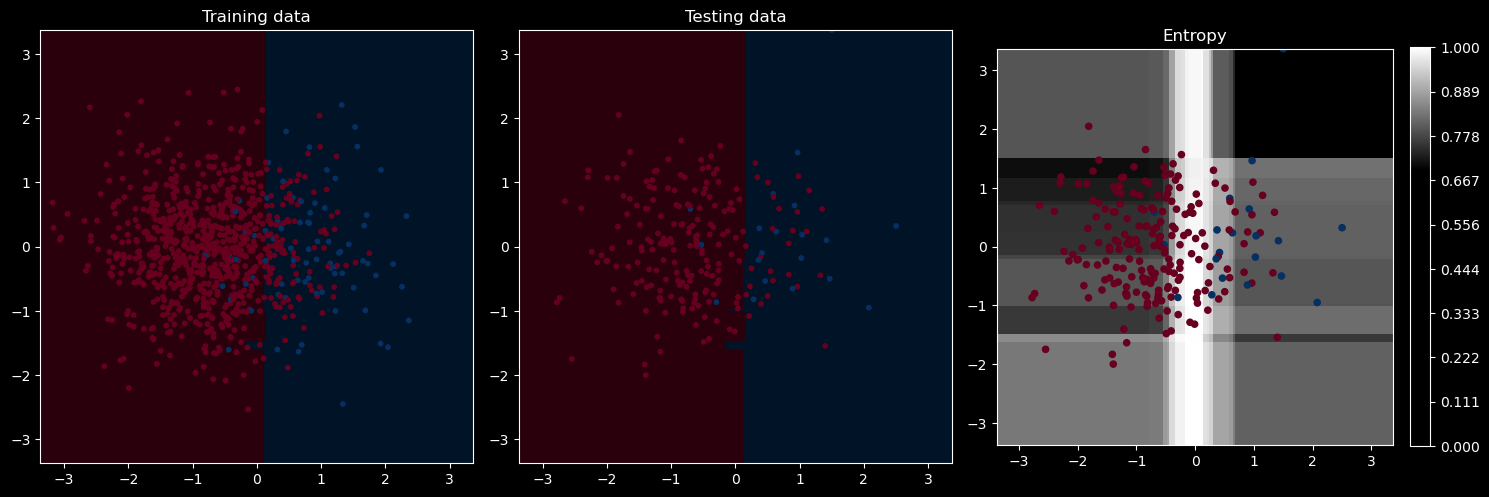

RandomForestClassifier(max_leaf_nodes=10)
              precision    recall  f1-score   support

           0       0.98      0.85      0.91       200
           1       0.37      0.85      0.52        20

    accuracy                           0.85       220
   macro avg       0.68      0.85      0.71       220
weighted avg       0.93      0.85      0.88       220



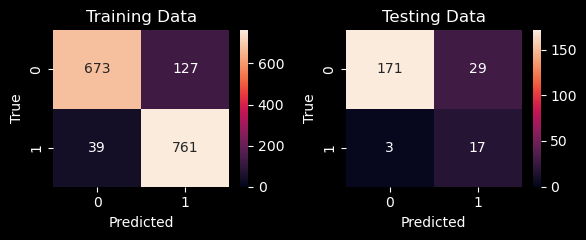

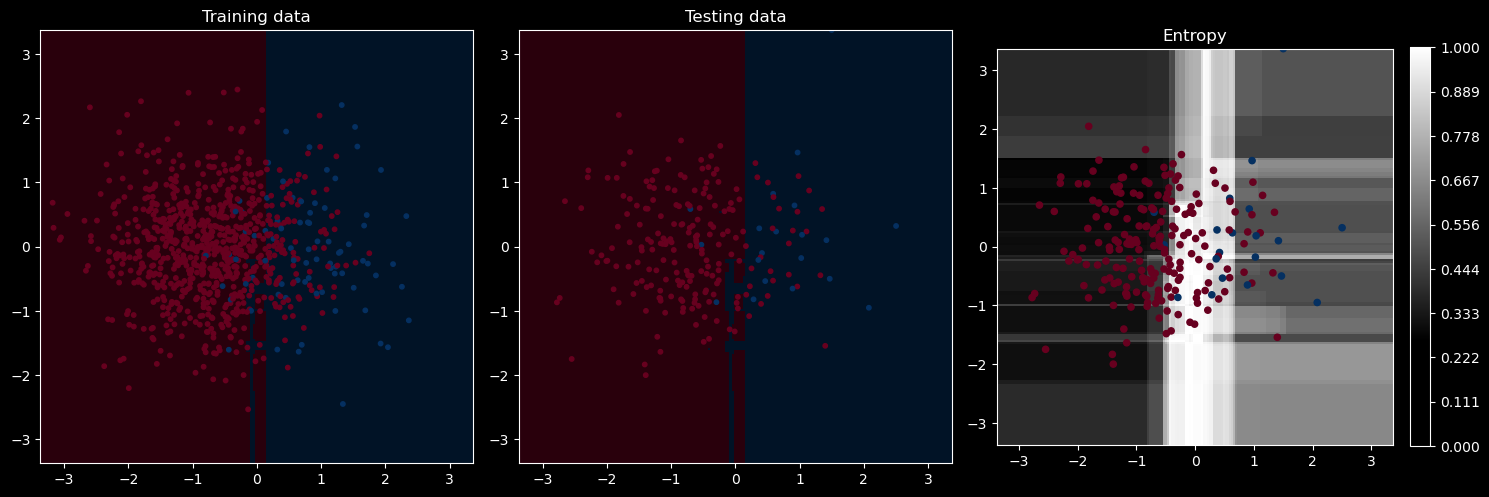

RandomForestClassifier(max_leaf_nodes=30)
              precision    recall  f1-score   support

           0       0.97      0.90      0.93       200
           1       0.42      0.75      0.54        20

    accuracy                           0.88       220
   macro avg       0.69      0.82      0.73       220
weighted avg       0.92      0.88      0.90       220



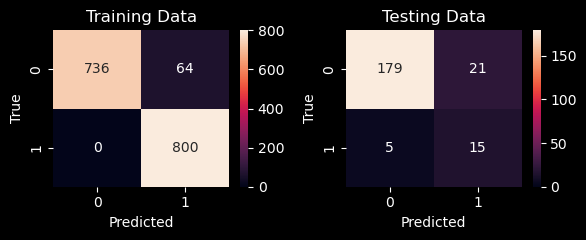

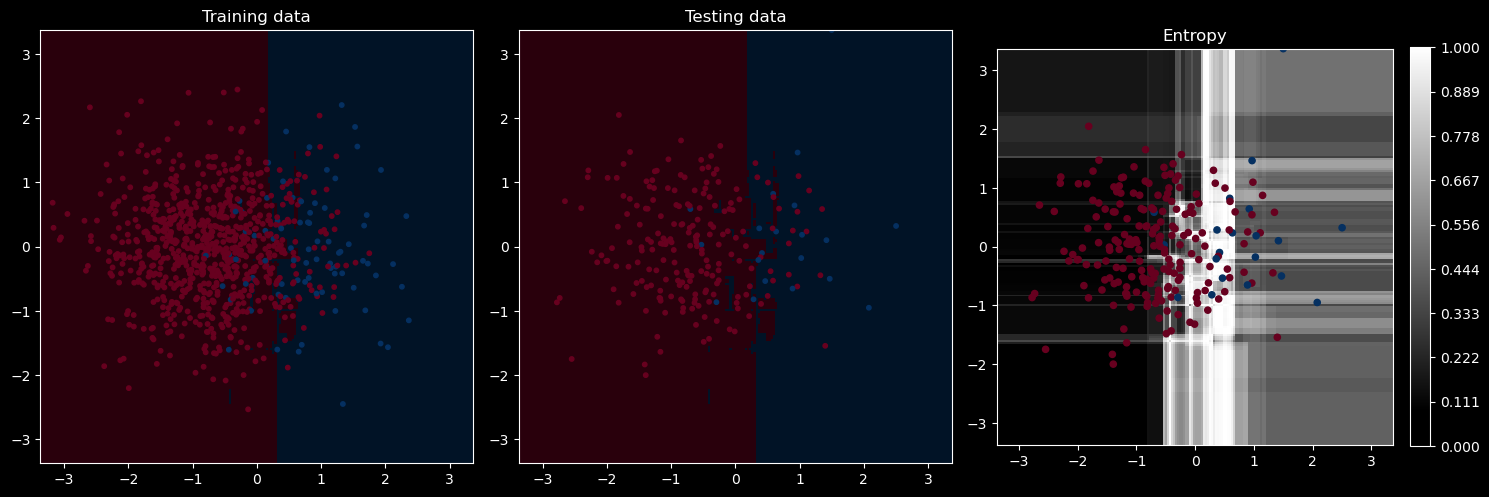

GradientBoostingClassifier(max_leaf_nodes=3, n_estimators=10)
              precision    recall  f1-score   support

           0       0.98      0.86      0.92       200
           1       0.39      0.85      0.53        20

    accuracy                           0.86       220
   macro avg       0.68      0.86      0.73       220
weighted avg       0.93      0.86      0.88       220



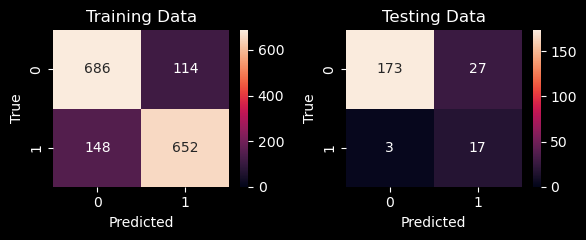

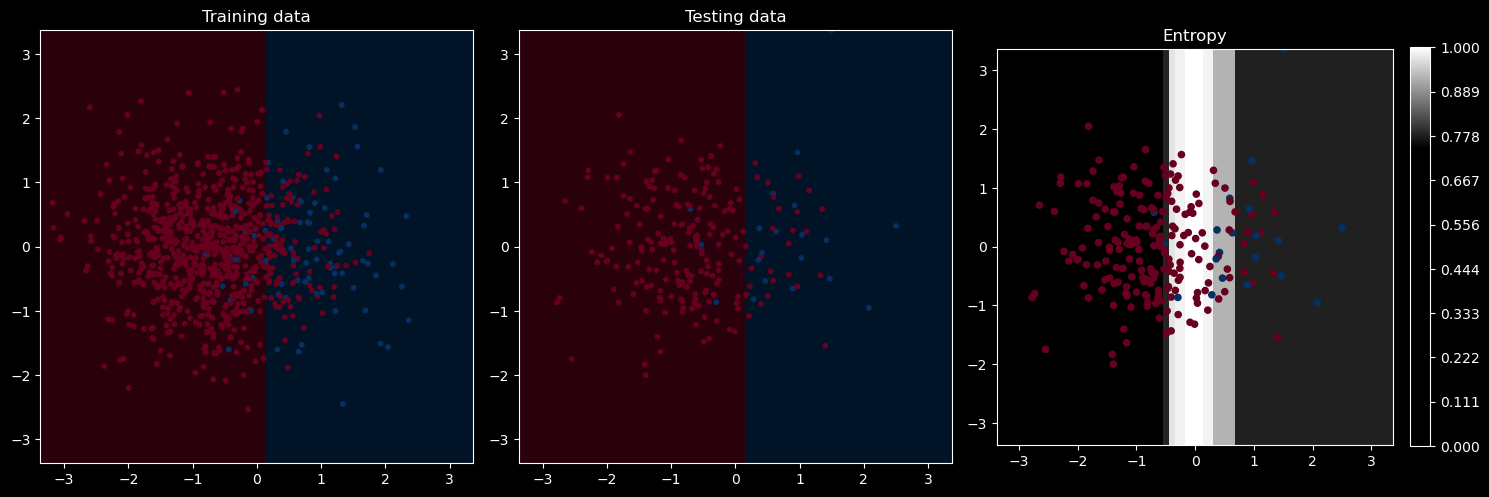

GradientBoostingClassifier(max_leaf_nodes=10, n_estimators=10)
              precision    recall  f1-score   support

           0       0.98      0.86      0.92       200
           1       0.39      0.85      0.53        20

    accuracy                           0.86       220
   macro avg       0.68      0.86      0.73       220
weighted avg       0.93      0.86      0.88       220



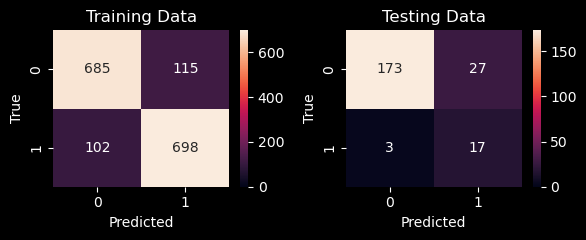

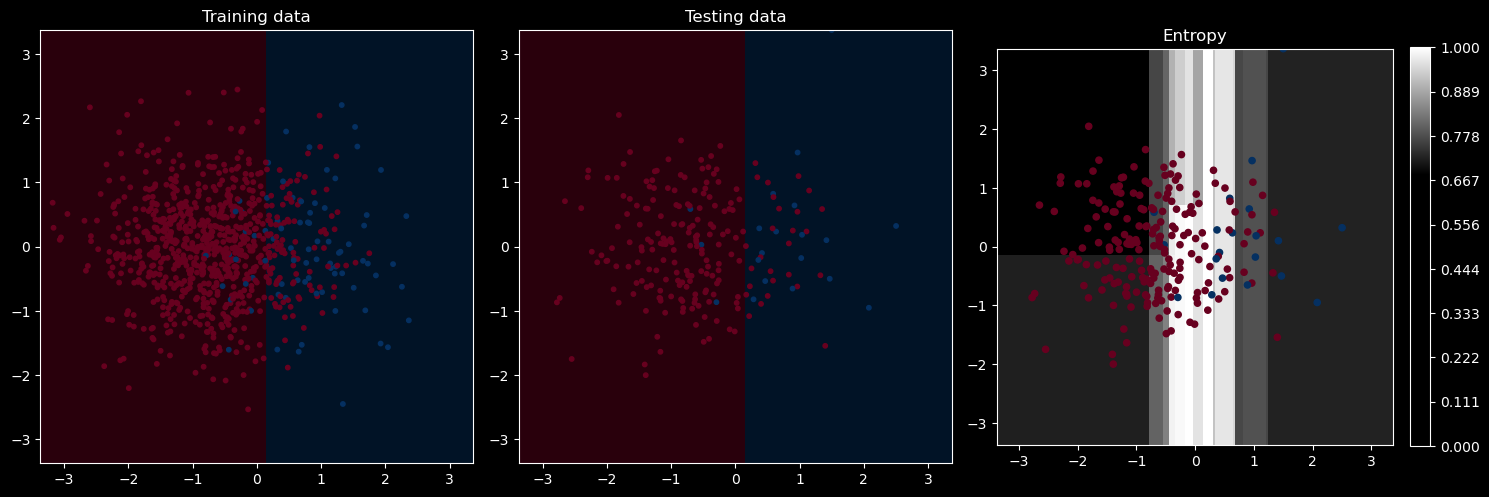

GradientBoostingClassifier(max_leaf_nodes=3)
              precision    recall  f1-score   support

           0       0.98      0.87      0.92       200
           1       0.38      0.80      0.52        20

    accuracy                           0.86       220
   macro avg       0.68      0.83      0.72       220
weighted avg       0.92      0.86      0.88       220



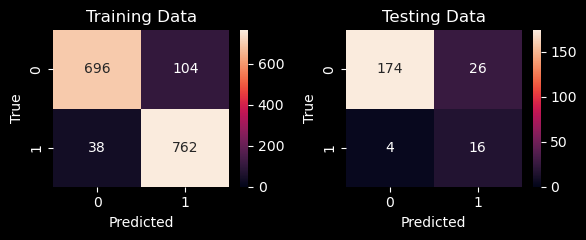

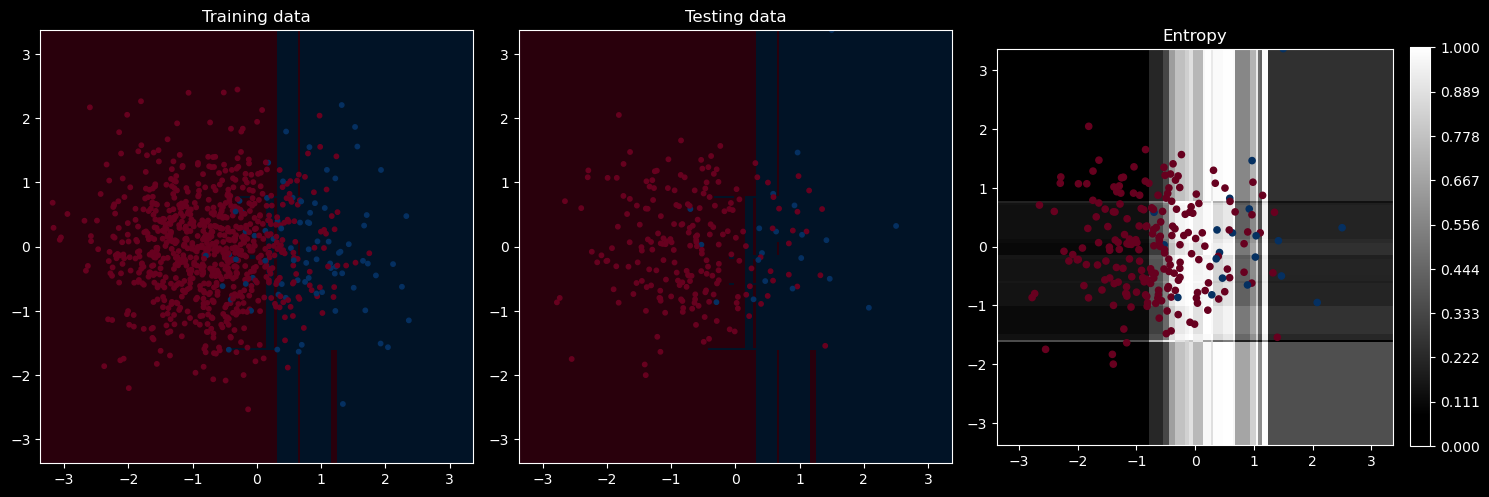

GradientBoostingClassifier(max_leaf_nodes=10)
              precision    recall  f1-score   support

           0       0.95      0.90      0.92       200
           1       0.32      0.50      0.39        20

    accuracy                           0.86       220
   macro avg       0.63      0.70      0.66       220
weighted avg       0.89      0.86      0.87       220



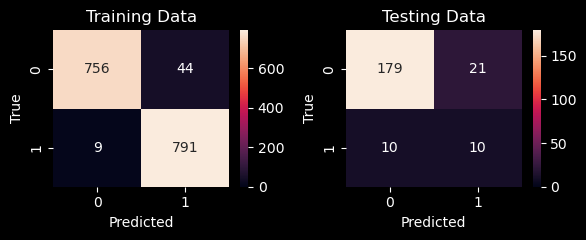

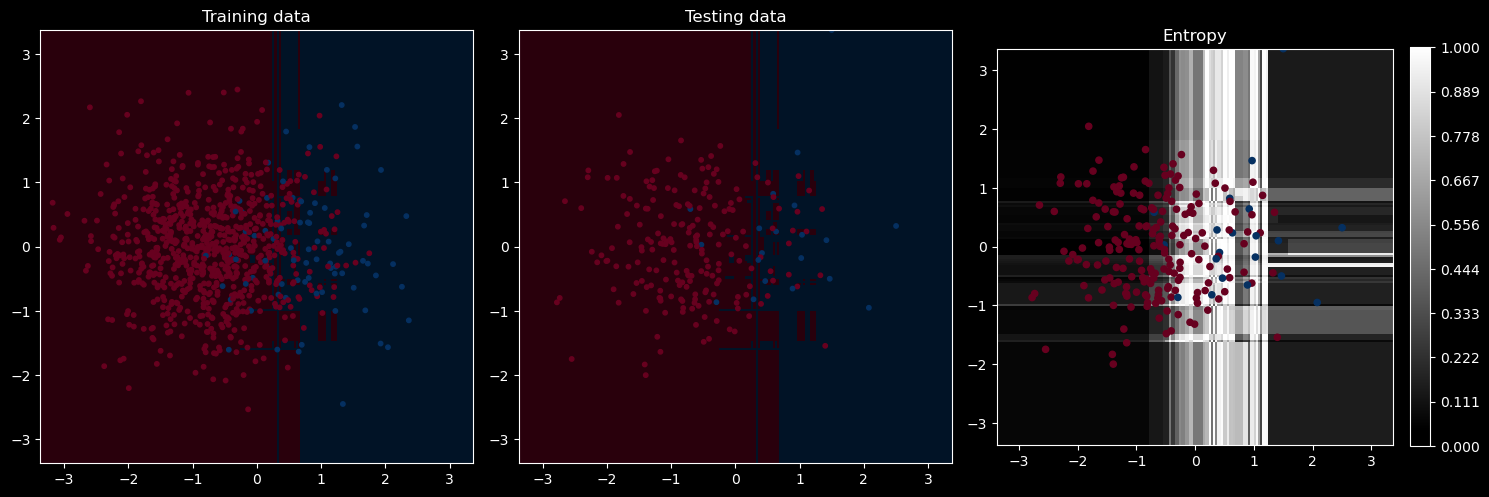

In [12]:
from sklearn.metrics import classification_report, confusion_matrix

for m in models:
    m.fit(X_train_res, y_train_res)
    y_train_res_pred = m.predict(X_train_res).astype(int)
    y_test_res_pred = m.predict(X_test).astype(int)
    
    print(m)
    print(classification_report(y_test, y_test_res_pred))
    
    conf_matrix_train = confusion_matrix(y_train_res, y_train_res_pred)
    conf_matrix_test = confusion_matrix(y_test, y_test_res_pred)
    
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(6, 2.5))
    
    sns.heatmap(conf_matrix_train, annot=True, vmin=0, fmt='d', ax=axes[0])
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("True")
    axes[0].set_title("Training Data")
    
    sns.heatmap(conf_matrix_test, annot=True, vmin=0, fmt='d', ax=axes[1])
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("True")
    axes[1].set_title("Testing Data")
    
    plt.tight_layout()
    plt.show()

    B, S = visualize_regions(m, MAX, 200)
    
    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15,5))
    
    extent = [-MAX,MAX,-MAX,MAX]
    
    cmap = "RdBu"
    axes[0].imshow(B, interpolation='none', extent=extent,cmap=cmap, alpha=0.4)
    axes[0].scatter(X_train[:,0], X_train[:,1], c=y_train, s=10, cmap=cmap);
    axes[0].set_aspect('equal')
    axes[0].set_title('Training data');
    
    axes[1].imshow(B, interpolation='none', extent=extent,cmap=cmap, alpha=0.4)
    axes[1].scatter(X_test[:,0], X_test[:,1], c=y_test, s=10, cmap=cmap);
    axes[1].set_aspect('equal')
    axes[1].set_title('Testing data');
    
    im = axes[2].imshow(S, interpolation='none', extent=extent,cmap='gray')
    axes[2].scatter(X_test[:,0], X_test[:,1], c=y_test, s=20, cmap=cmap);
    axes[2].set_aspect('equal')
    axes[2].set_title('Entropy')
    cbar = fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
    cbar.set_ticks(np.linspace(0, math.log(y.max()+1,2), 10))

    plt.tight_layout()
    plt.show()
# end

## 6. Review

- **Imbalance makes accuracy meaningless.** At 10:1, always predicting the majority scores ~91% with
  zero recall on the class you care about. Read per-class recall and the confusion matrix.
- **Oversampling duplicates minority points until the classes match**, which fixes the ratio without
  adding information — so the duplicated points can be memorized.
- **Undersampling is the alternative**: discard majority points instead. It avoids duplication but
  throws away real data.
- **Resample the training split only.** The test set must keep the real ratio, so split first,
  resample second.
- **`imblearn.RandomOverSampler` is the one-call version** of the manual index sampling, with
  scikit-learn's API conventions.
- **The trade is recall for precision** on the minority class. Which side to prefer is an
  application question — see `U1-7_Imbalance-4_ClassWeights`.